In [50]:
import numpy as np
import pandas as pd
import os, json

In [51]:
def get_result_json_B(dataset, encoder, model, root, attack:bool, verbose=False):
    attack_ = "B_eval" if attack else "clean"
    log_dir = os.path.join(root, dataset, encoder, model, attack_)
    timestamps = os.listdir(log_dir)
    timestamps.sort()
    latest_timestamp = timestamps[-1]
    log_dir = os.path.join(log_dir, latest_timestamp, dataset, encoder, model)
    timestamps = os.listdir(log_dir)
    timestamps.sort()
    latest_timestamp = timestamps[-1]
    log_dir = os.path.join(log_dir, latest_timestamp)
    files = os.listdir(log_dir)
    num_seeds = len([f for f in files if f.startswith('seed')])
    log_files = [f for f in files if f.endswith('.json')]
    assert f"{num_seeds}_seeds" in log_files[0], f"Number of seeds {num_seeds} inconsistent with log file {log_files[0]}"
    if verbose:
        print(f'Found {len(log_files)} log files in {log_dir}')
    results = json.load(open(f'{log_dir}/{log_files[0]}', 'r'))
    return results

def get_result_json(dataset, encoder, model, root, attack:bool=False, verbose=False):
    log_dir = f'{root}/{dataset}/{encoder}/{model}'
    if verbose and not os.path.exists(log_dir):
        print(f'Log directory does not exist: {log_dir}')
        return None
    timestamps = os.listdir(log_dir)
    timestamps.sort()
    latest_timestamp = timestamps[-1]
    log_dir = f'{log_dir}/{latest_timestamp}'
    files = os.listdir(log_dir)
    num_seeds = len([f for f in files if f.startswith('seed')])
    log_files = [f for f in files if f.endswith('.json')]
    if len(log_files) != 1:
        # f"Expected exactly one log file, but found {len(log_files)} in {log_dir}"
        return get_result_json_B(dataset, encoder, model, root, attack, verbose)

    assert f"{num_seeds}_seeds" in log_files[0], f"Number of seeds {num_seeds} inconsistent with log file {log_files[0]}"
    if verbose:
        print(f'Found {len(log_files)} log files in {log_dir}')
    results = json.load(open(f'{log_dir}/{log_files[0]}', 'r'))
    return results

In [52]:
def show_results(df:pd.DataFrame, model_name:str):
    for dataset in df["dataset"].unique():
        backbone = "backbone" if "backbone" in df.columns else "encoder"
        for bb in df[backbone].unique():
            row = df[(df["dataset"]==dataset) & (df[backbone]==bb) & (df["model"]==model_name)].iloc[0]
            print(f"Dataset: {dataset}, Backbone: {bb}, Model: {model_name}")
            print(f"{row['AUC_mean']*100:.2f} ± {row['AUC_std']*100:.2f}")
            print(f"{row['F1_mean']*100:.2f} ± {row['F1_std']*100:.2f}")
            print(f"{row['DP_mean']*100:.2f} ± {row['DP_std']*100:.2f}")
            print(f"{row['EO_mean']*100:.2f} ± {row['EO_std']*100:.2f}")
            print('--------------------------------')

In [53]:
def collect_rerun_results(datasets, encoders, models, path, attack_mode:str, verbose=False):
    lst_results = []
    for dataset in datasets:
        for encoder in encoders:
            for model in models:
                results = get_result_json(dataset, encoder, model, path, attack_mode != "no_attack", verbose)
                if results is None:
                    continue
                results['results']["dataset"] = dataset
                results['results']["encoder"] = encoder
                results['results']["model"] = model
                results['results']["attack_mode"] = attack_mode
                lst_results.append(results['results'])
    df_results = pd.DataFrame(lst_results).sort_values(by=["dataset", "encoder", "model"])
    return df_results

def concat_clean_and_attacked_results(df_clean:pd.DataFrame, df_attack:pd.DataFrame, attack_mode:str, include_ratio:bool=True):
    assert np.array_equal(
        df_clean[["dataset", "encoder"]].values,
        df_attack[["dataset", "encoder"]].values
    )
    numeric_cols = [col for col in df_clean.columns if df_clean[col].dtype in [np.float64, np.float32, np.int64, np.int32] and col not in ["dataset", "encoder", "model"]]
    if include_ratio:
        df_ratio = df_attack.copy()
        for col in numeric_cols:
            df_ratio[col] = df_attack[col] / df_clean[col]
        df_ratio[["dataset", "encoder", "model"]] = df_attack[["dataset", "encoder", "model"]]
        df_ratio["attack_mode"] = "ratio"
        df_concat = pd.concat([df_clean, df_attack, df_ratio], ignore_index=True)
        df_concat["attack_mode"] = pd.Categorical(df_concat["attack_mode"], categories=["none", attack_mode, "ratio"], ordered=True)
    else:
        df_concat = pd.concat([df_clean, df_attack], ignore_index=True)
        df_concat["attack_mode"] = pd.Categorical(df_concat["attack_mode"], categories=["none", attack_mode], ordered=True)
    df_concat = df_concat.sort_values(by=["dataset", "encoder", "model", "attack_mode"])
    df_concat = df_concat[["dataset", "encoder", "model", "attack_mode"] + numeric_cols]
    return df_concat

# After 11 Jan 2026

In [64]:
datasets = ['bail', 'pokec_z', 'pokec_n', 'nba', 'german']
encoders = ['gcn', 'gat', 'gin', 'sage', 'sgc']
models = ['edge_adder']

In [75]:
attack_mode = "tuned_nifa"
path = f"../logs/rerun_expB_tuned_nifa"
df_ea_tuned = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_ea_tuned.shape

(25, 15)

In [68]:
out_dir = "./20260111/ea/"
os.makedirs(out_dir, exist_ok=True)
fn = os.path.join(out_dir, "df_ea_tuned.csv")
df_ea_tuned.to_csv(fn, index=False)

In [76]:
df_ea_no_attack = pd.read_csv("./20260105/ea/df_ea_no_attack.csv")
df_ea = pd.concat([df_ea_no_attack, df_ea_tuned], ignore_index=True)
df_ea["attack_mode"] = pd.Categorical(df_ea["attack_mode"], categories=["no_attack", "tuned_nifa"], ordered=True)
df_ea = df_ea.sort_values(by=["dataset", "encoder", "model", "attack_mode"])
pt_ea = df_ea.pivot_table(index=["dataset", "encoder", "model"], columns="attack_mode", values=["AUC_mean", "F1_mean", "DP_mean", "EO_mean"], observed=False)
values = ["AUC_mean", "F1_mean", "DP_mean", "EO_mean"]
pt_ea = pt_ea[values]

In [77]:
round(pt_ea*100, 2)

AUC_mean              F1_mean             \
attack_mode                no_attack tuned_nifa no_attack tuned_nifa   
dataset encoder model                                                  
bail    gat     edge_adder     93.32      91.53     85.39      81.45   
        gcn     edge_adder     89.05      87.90     78.98      76.95   
        gin     edge_adder     83.58      84.72     72.98      72.91   
        sage    edge_adder     90.50      89.89     81.73      80.53   
        sgc     edge_adder     89.95      88.23     81.03      79.02   
german  gat     edge_adder     48.86      50.57     49.41      41.18   
        gcn     edge_adder     61.36      62.47     52.09      47.96   
        gin     edge_adder     68.02      68.94     70.44      71.28   
        sage    edge_adder     72.69      72.29     74.51      77.06   
        sgc     edge_adder     62.64      64.70     47.75      69.12   
nba     gat     edge_adder     75.55      75.56     73.56      72.62   
        gcn     edge_adder     73.36      68.72     69.81      67.12   
        gin     edge_adder     59.13      57.83     52.91      51.49   
        sage    edge_adder     64.79      64.23     53.23      55.39   
        sgc     edge_adder     72.29      70.83     65.20      65.58   
pokec_n gat     edge_adder     75.23      74.14     66.48      65.79   
        gcn     edge_adder     74.74      72.85     66.83      64.91   
        gin     edge_adder     73.42      70.49     64.86      63.31   
        sage    edge_adder     74.64      73.12     66.78      66.54   
        sgc     edge_adder     74.98      74.23     67.21      65.76   
pokec_z gat     edge_adder     77.94      77.36     69.64      70.39   
        gcn     edge_adder     76.98      74.91     70.92      69.28   
        gin     edge_adder     74.25      71.63     68.57      67.02   
        sage    edge_adder     77.95      76.59     71.37      71.12   
        sgc     edge_adder     76.77      76.42     71.00      70.89   

                             DP_mean              EO_mean             
attack_mode                no_attack tuned_nifa no_attack tuned_nifa  
dataset encoder model                                                 
bail    gat     edge_adder      7.48       7.24      5.08       6.05  
        gcn     edge_adder      7.61       9.44      3.56       4.29  
        gin     edge_adder      6.95      12.46      5.15       6.86  
        sage    edge_adder      9.02      14.22      8.18      10.97  
        sgc     edge_adder      7.11       7.53      5.17       4.28  
german  gat     edge_adder      0.00       0.00      0.00       0.00  
        gcn     edge_adder      2.98       4.32      3.31       4.32  
        gin     edge_adder      9.02       6.75      8.12       3.99  
        sage    edge_adder      8.01       9.31      4.22       5.37  
        sgc     edge_adder      1.59       2.75      1.71       2.80  
nba     gat     edge_adder     22.73      23.22     14.67      11.33  
        gcn     edge_adder     23.72      39.46     10.67      35.00  
        gin     edge_adder     11.97       5.30     11.33       9.33  
        sage    edge_adder     13.53      10.27     13.67      10.00  
        sgc     edge_adder     25.18      42.14     11.00      32.67  
pokec_n gat     edge_adder      1.24       2.04      1.42       3.16  
        gcn     edge_adder      0.72       2.14      1.41       3.09  
        gin     edge_adder      2.11       1.61      2.96       2.30  
        sage    edge_adder      1.96       5.43      1.70       4.13  
        sgc     edge_adder      0.85       2.05      1.86       2.41  
pokec_z gat     edge_adder      4.41       3.80      4.40       3.49  
        gcn     edge_adder      3.42       1.11      2.80       1.14  
        gin     edge_adder      2.10       1.87      2.47       2.04  
        sage    edge_adder      4.87       1.72      5.51       2.05  
        sgc     edge_adder      4.01       5.19      3.01       3.47

In [66]:
df_ea_tuned

,AUC_mean,AUC_std,F1_mean,F1_std,ACC_mean,ACC_std,DP_mean,DP_std,EO_mean,EO_std,name,dataset,encoder,model,attack_mode
1,0.915317,0.006180,0.814549,0.016302,0.872197,0.008874,0.072359,0.006030,0.060462,0.012889,edge_adder_bail_gat_alpha:0.5_lr_sp:0.5_env_nu...,bail,gat,edge_adder,tuned
0,0.879018,0.005555,0.769455,0.008801,0.823501,0.007447,0.094427,0.003354,0.042856,0.007414,edge_adder_bail_gcn_alpha:0.5_lr_sp:0.5_env_nu...,bail,gcn,edge_adder,tuned
2,0.847248,0.008185,0.729109,0.011544,0.775037,0.016108,0.124598,0.014771,0.068646,0.013048,edge_adder_bail_gin_alpha:0.5_lr_sp:0.5_env_nu...,bail,gin,edge_adder,tuned
3,0.898881,0.005521,0.805276,0.006838,0.854376,0.006745,0.142210,0.015980,0.109726,0.011506,edge_adder_bail_sage_alpha:0.5_lr_sp:0.5_env_n...,bail,sage,edge_adder,tuned
4,0.882306,0.000872,0.790201,0.003478,0.843039,0.003807,0.075272,0.001829,0.042815,0.001352,edge_adder_bail_sgc_alpha:0.5_lr_sp:0.5_env_nu...,bail,sgc,edge_adder,tuned
21,0.505707,0.032843,0.411765,0.411765,0.500000,0.200000,0.000000,0.000000,0.000000,0.000000,edge_adder_german_gat_alpha:0.5_lr_sp:0.5_env_...,german,gat,edge_adder,tuned
20,0.624709,0.041597,0.479606,0.305922,0.515600,0.159373,0.043167,0.056904,0.043172,0.043398,edge_adder_german_gcn_alpha:0.5_lr_sp:0.5_env_...,german,gcn,edge_adder,tuned
22,0.689402,0.021203,0.712809,0.066459,0.638800,0.054260,0.067499,0.032728,0.039916,0.023114,edge_adder_german_gin_alpha:0.5_lr_sp:0.5_env_...,german,gin,edge_adder,tuned
23,0.722872,0.008539,0.770628,0.020704,0.693600,0.017727,0.093085,0.018156,0.053676,0.020484,edge_adder_german_sage_alpha:0.5_lr_sp:0.5_env...,german,sage,edge_adder,tuned
24,0.646971,0.026568,0.691214,0.263475,0.631600,0.136943,0.027523,0.037681,0.028046,0.038982,edge_adder_german_sgc_alpha:0.5_lr_sp:0.5_env_...,german,sgc,edge_adder,tuned


# After 05 Jan 2026

## Vanilla

In [54]:
datasets = ['bail', 'pokec_z', 'pokec_n', 'nba', 'german']
encoders = ['gcn', 'gat', 'gin', 'sage', 'sgc']
models = ['vanilla']

In [22]:
attack_mode = "no_attack"
path = f"../logs/final_B_optuna_big"
df_vanilla_no_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_vanilla_no_attack.shape

(25, 15)

In [ ]:
out_dir = "./20260105/vanilla/"
os.makedirs(out_dir, exist_ok=True)
fn = os.path.join(out_dir, "df_vanilla_no_attack.csv")
df_vanilla_no_attack.to_csv(fn, index=False)

In [23]:
attack_mode = "degree"
path = f"../logs/final_B_optuna_big"
df_vanilla_degree = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_vanilla_degree.shape

(25, 15)

In [ ]:
out_dir = "./20260105/vanilla/"
os.makedirs(out_dir, exist_ok=True)
fn = os.path.join(out_dir, "df_vanilla_degree.csv")
df_vanilla_degree.to_csv(fn, index=False)

In [35]:
df_vanilla = pd.concat([df_vanilla_no_attack, df_vanilla_degree], ignore_index=True)
df_vanilla["attack_mode"] = pd.Categorical(df_vanilla["attack_mode"], categories=["no_attack", "degree"], ordered=True)
df_vanilla = df_vanilla.sort_values(by=["dataset", "encoder", "model", "attack_mode"])
pt_vanilla = df_vanilla.pivot_table(index=["dataset", "encoder", "model"], columns="attack_mode", values=["AUC_mean", "F1_mean", "DP_mean", "EO_mean"], observed=False)
values = ["AUC_mean", "F1_mean", "DP_mean", "EO_mean"]
pt_vanilla = pt_vanilla[values]

In [ ]:
out_dir = "./20260105/ea/"
os.makedirs(out_dir, exist_ok=True)
fn = os.path.join(out_dir, "pt_vanilla.csv")
pt_vanilla.to_csv(fn, index=False)

In [36]:
round(pt_vanilla, 4) * 100

AUC_mean          F1_mean          DP_mean         \
attack_mode             no_attack degree no_attack degree no_attack degree   
dataset encoder model                                                        
bail    gat     vanilla     94.72  93.64     86.65  84.79      7.14   7.67   
        gcn     vanilla     88.10  88.12     77.34  77.31      8.66   8.79   
        gin     vanilla     84.51  84.45     72.07  71.98      9.41   9.75   
        sage    vanilla     91.18  91.15     79.83  79.74      5.17   5.25   
        sgc     vanilla     89.24  89.23     79.48  79.32      4.76   4.65   
german  gat     vanilla     48.05  49.09     50.68  32.94      0.73   0.00   
        gcn     vanilla     65.26  65.24     63.11  62.79     12.96  10.98   
        gin     vanilla     68.93  68.80     77.45  77.59     20.65  19.54   
        sage    vanilla     64.19  64.32     50.52  51.93     17.02  17.01   
        sgc     vanilla     68.42  68.39     59.13  58.92     24.69  24.76   
nba     gat     vanilla     66.27  65.80     62.32  61.83     21.04  19.04   
        gcn     vanilla     73.45  72.79     66.34  66.84     26.15  31.39   
        gin     vanilla     54.63  54.90     38.36  38.25      7.04   6.76   
        sage    vanilla     64.44  63.61     52.64  52.63     12.59  11.40   
        sgc     vanilla     72.30  71.76     62.66  61.78     28.52  31.87   
pokec_n gat     vanilla     75.90  73.19     64.71  66.38      1.86  13.22   
        gcn     vanilla     74.21  74.01     65.02  64.30      1.55   5.76   
        gin     vanilla     70.57  69.27     58.73  57.24      2.22  11.10   
        sage    vanilla     72.83  70.27     66.75  66.83      2.09   7.16   
        sgc     vanilla     75.68  75.56     66.94  67.50      1.55   4.43   
pokec_z gat     vanilla     78.74  76.83     69.17  69.47      4.15  15.41   
        gcn     vanilla     78.17  77.42     70.56  70.10      4.44  15.45   
        gin     vanilla     73.58  71.95     64.04  63.21      3.63  15.76   
        sage    vanilla     75.13  72.38     67.95  66.94      2.32  14.44   
        sgc     vanilla     77.71  76.93     71.00  70.91      3.48  14.34   

                          EO_mean         
attack_mode             no_attack degree  
dataset encoder model                     
bail    gat     vanilla      4.72   4.51  
        gcn     vanilla      4.30   4.43  
        gin     vanilla      6.43   6.68  
        sage    vanilla      2.07   1.99  
        sgc     vanilla      2.76   2.83  
german  gat     vanilla      0.75   0.00  
        gcn     vanilla     11.86  10.00  
        gin     vanilla     17.15  16.42  
        sage    vanilla     16.23  15.80  
        sgc     vanilla     19.17  19.08  
nba     gat     vanilla     23.00  20.67  
        gcn     vanilla     18.33  20.33  
        gin     vanilla      6.33   7.33  
        sage    vanilla     11.33  11.67  
        sgc     vanilla     18.00  23.67  
pokec_n gat     vanilla      2.63   9.06  
        gcn     vanilla      2.16   5.72  
        gin     vanilla      3.65  13.35  
        sage    vanilla      2.36   5.98  
        sgc     vanilla      3.09   4.74  
pokec_z gat     vanilla      3.45  12.06  
        gcn     vanilla      2.46  11.46  
        gin     vanilla      3.92  15.21  
        sage    vanilla      2.79  13.58  
        sgc     vanilla      3.32  10.48

## EdgeAdder

In [55]:
datasets = ['bail', 'pokec_z', 'pokec_n', 'nba', 'german']
encoders = ['gcn', 'gat', 'gin', 'sage', 'sgc']
models = ['edge_adder']

In [ ]:
attack_mode = "no_attack"
path = f"../logs/final_B_optuna_big"
df_ea_no_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_ea_no_attack.shape

(25, 15)

In [ ]:
out_dir = "./20260105/vanilla/"
os.makedirs(out_dir, exist_ok=True)
fn = os.path.join(out_dir, "df_ea_no_attack.csv")
df_ea_no_attack.to_csv(fn, index=False)

In [ ]:
attack_mode = "degree"
path = f"../logs/rerun_expB_tuned_nifa" # f"../logs/final_B_optuna_big"
df_ea_degree = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_ea_degree.shape

(25, 15)

In [ ]:
out_dir = "./20260105/vanilla/"
os.makedirs(out_dir, exist_ok=True)
fn = os.path.join(out_dir, "df_ea_degree.csv")
df_ea_degree.to_csv(fn, index=False)

In [37]:
df_ea = pd.concat([df_ea_no_attack, df_ea_degree], ignore_index=True)
df_ea["attack_mode"] = pd.Categorical(df_ea["attack_mode"], categories=["no_attack", "degree"], ordered=True)
df_ea = df_ea.sort_values(by=["dataset", "encoder", "model", "attack_mode"])
pt_ea = df_ea.pivot_table(index=["dataset", "encoder", "model"], columns="attack_mode", values=["AUC_mean", "F1_mean", "DP_mean", "EO_mean"], observed=False)
values = ["AUC_mean", "F1_mean", "DP_mean", "EO_mean"]
pt_ea = pt_ea[values]

In [ ]:
out_dir = "./20260105/ea/"
os.makedirs(out_dir, exist_ok=True)
fn = os.path.join(out_dir, "pt_ea.csv")
pt_ea.to_csv(fn, index=False)

In [38]:
round(pt_ea, 4) * 100

AUC_mean          F1_mean          DP_mean         \
attack_mode                no_attack degree no_attack degree no_attack degree   
dataset encoder model                                                           
bail    gat     edge_adder     93.32  93.49     85.39  84.83      7.48   7.63   
        gcn     edge_adder     89.05  89.07     78.98  78.92      7.61   7.70   
        gin     edge_adder     83.58  83.55     72.98  72.92      6.95   7.51   
        sage    edge_adder     90.50  90.44     81.73  81.47      9.02   9.06   
        sgc     edge_adder     89.95  89.94     81.03  80.95      7.11   7.12   
german  gat     edge_adder     48.86  50.15     49.41  41.18      0.00   0.00   
        gcn     edge_adder     61.36  61.35     52.09  51.86      2.98   2.62   
        gin     edge_adder     68.02  67.91     70.44  70.75      9.02   7.88   
        sage    edge_adder     72.69  72.67     74.51  74.41      8.01   8.38   
        sgc     edge_adder     62.64  62.64     47.75  47.60      1.59   1.57   
nba     gat     edge_adder     75.55  75.22     73.56  74.78     22.73  23.70   
        gcn     edge_adder     73.36  73.21     69.81  68.29     23.72  25.22   
        gin     edge_adder     59.13  59.18     52.91  52.92     11.97  10.26   
        sage    edge_adder     64.79  64.67     53.23  52.83     13.53  13.15   
        sgc     edge_adder     72.29  72.57     65.20  66.24     25.18  34.31   
pokec_n gat     edge_adder     75.23  73.03     66.48  65.77      1.24   7.03   
        gcn     edge_adder     74.74  74.92     66.83  66.87      0.72   3.39   
        gin     edge_adder     73.42  72.37     64.86  65.10      2.11   7.31   
        sage    edge_adder     74.64  73.50     66.78  67.46      1.96   5.95   
        sgc     edge_adder     74.98  75.10     67.21  67.55      0.85   1.71   
pokec_z gat     edge_adder     77.94  71.56     69.64  66.91      4.41  24.26   
        gcn     edge_adder     76.98  76.37     70.92  70.24      3.42  14.83   
        gin     edge_adder     74.25  73.56     68.57  68.24      2.10   5.08   
        sage    edge_adder     77.95  76.86     71.37  71.05      4.87  16.97   
        sgc     edge_adder     76.77  76.10     71.00  70.88      4.01   9.40   

                             EO_mean         
attack_mode                no_attack degree  
dataset encoder model                        
bail    gat     edge_adder      5.08   4.32  
        gcn     edge_adder      3.56   3.54  
        gin     edge_adder      5.15   5.58  
        sage    edge_adder      8.18   8.02  
        sgc     edge_adder      5.17   4.99  
german  gat     edge_adder      0.00   0.00  
        gcn     edge_adder      3.31   2.93  
        gin     edge_adder      8.12   7.33  
        sage    edge_adder      4.22   4.96  
        sgc     edge_adder      1.71   1.37  
nba     gat     edge_adder     14.67  12.33  
        gcn     edge_adder     10.67  12.00  
        gin     edge_adder     11.33   9.33  
        sage    edge_adder     13.67  14.67  
        sgc     edge_adder     11.00  22.00  
pokec_n gat     edge_adder      1.42   6.35  
        gcn     edge_adder      1.41   2.40  
        gin     edge_adder      2.96   6.54  
        sage    edge_adder      1.70   4.82  
        sgc     edge_adder      1.86   2.10  
pokec_z gat     edge_adder      4.40  21.82  
        gcn     edge_adder      2.80  11.40  
        gin     edge_adder      2.47   5.07  
        sage    edge_adder      5.51  15.05  
        sgc     edge_adder      3.01   6.69

## Compare

### Clean

In [78]:
df1 = df_vanilla.loc[df_vanilla["attack_mode"] == "no_attack", :]
df2 = df_ea.loc[df_ea["attack_mode"] == "no_attack", :]
pt_clean = pd.concat([df1, df2], axis=0)
pt_clean["model"] = pd.Categorical(pt_clean["model"], categories=["vanilla", "edge_adder"], ordered=True)
pt_clean = pt_clean.pivot_table(index=["dataset", "encoder"], columns="model", values=["AUC_mean", "F1_mean", "DP_mean", "EO_mean"], observed=False)
values = ["AUC_mean", "F1_mean", "DP_mean", "EO_mean"]
pt_clean = pt_clean[values]
round(pt_clean, 4) * 100

AUC_mean            F1_mean            DP_mean             \
model            vanilla edge_adder vanilla edge_adder vanilla edge_adder   
dataset encoder                                                             
bail    gat        94.72      93.32   86.65      85.39    7.14       7.48   
        gcn        88.10      89.05   77.34      78.98    8.66       7.61   
        gin        84.51      83.58   72.07      72.98    9.41       6.95   
        sage       91.18      90.50   79.83      81.73    5.17       9.02   
        sgc        89.24      89.95   79.48      81.03    4.76       7.11   
german  gat        48.05      48.86   50.68      49.41    0.73       0.00   
        gcn        65.26      61.36   63.11      52.09   12.96       2.98   
        gin        68.93      68.02   77.45      70.44   20.65       9.02   
        sage       64.19      72.69   50.52      74.51   17.02       8.01   
        sgc        68.42      62.64   59.13      47.75   24.69       1.59   
nba     gat        66.27      75.55   62.32      73.56   21.04      22.73   
        gcn        73.45      73.36   66.34      69.81   26.15      23.72   
        gin        54.63      59.13   38.36      52.91    7.04      11.97   
        sage       64.44      64.79   52.64      53.23   12.59      13.53   
        sgc        72.30      72.29   62.66      65.20   28.52      25.18   
pokec_n gat        75.90      75.23   64.71      66.48    1.86       1.24   
        gcn        74.21      74.74   65.02      66.83    1.55       0.72   
        gin        70.57      73.42   58.73      64.86    2.22       2.11   
        sage       72.83      74.64   66.75      66.78    2.09       1.96   
        sgc        75.68      74.98   66.94      67.21    1.55       0.85   
pokec_z gat        78.74      77.94   69.17      69.64    4.15       4.41   
        gcn        78.17      76.98   70.56      70.92    4.44       3.42   
        gin        73.58      74.25   64.04      68.57    3.63       2.10   
        sage       75.13      77.95   67.95      71.37    2.32       4.87   
        sgc        77.71      76.77   71.00      71.00    3.48       4.01   

                EO_mean             
model           vanilla edge_adder  
dataset encoder                     
bail    gat        4.72       5.08  
        gcn        4.30       3.56  
        gin        6.43       5.15  
        sage       2.07       8.18  
        sgc        2.76       5.17  
german  gat        0.75       0.00  
        gcn       11.86       3.31  
        gin       17.15       8.12  
        sage      16.23       4.22  
        sgc       19.17       1.71  
nba     gat       23.00      14.67  
        gcn       18.33      10.67  
        gin        6.33      11.33  
        sage      11.33      13.67  
        sgc       18.00      11.00  
pokec_n gat        2.63       1.42  
        gcn        2.16       1.41  
        gin        3.65       2.96  
        sage       2.36       1.70  
        sgc        3.09       1.86  
pokec_z gat        3.45       4.40  
        gcn        2.46       2.80  
        gin        3.92       2.47  
        sage       2.79       5.51  
        sgc        3.32       3.01

In [79]:
pt_clean["DP_mean"]

model             vanilla  edge_adder
dataset encoder                      
bail    gat      0.071442    0.074845
        gcn      0.086637    0.076114
        gin      0.094147    0.069475
        sage     0.051660    0.090218
        sgc      0.047566    0.071122
german  gat      0.007270    0.000000
        gcn      0.129596    0.029774
        gin      0.206465    0.090248
        sage     0.170240    0.080142
        sgc      0.246904    0.015889
nba     gat      0.210367    0.227273
        gcn      0.261483    0.237161
        gin      0.070415    0.119697
        sage     0.125917    0.135327
        sgc      0.285167    0.251754
pokec_n gat      0.018611    0.012373
        gcn      0.015470    0.007194
        gin      0.022206    0.021129
        sage     0.020917    0.019577
        sgc      0.015498    0.008527
pokec_z gat      0.041514    0.044057
        gcn      0.044447    0.034230
        gin      0.036309    0.020977
        sage     0.023158    0.048676
        sgc      0.034828    0.040082

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Helper to plot a pivot as a heatmap with matplotlib only
def heatmap_from_pivot(pivot: pd.DataFrame, title: str, xlabel="encoder", ylabel="dataset"):
    fig = plt.figure(figsize=(6, 4), dpi=150)
    ax = plt.gca()
    im = ax.imshow(pivot.values, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_xticklabels(pivot.columns.tolist())
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_yticklabels(pivot.index.tolist())

    # annotate values
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", fontsize=6)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


In [100]:
def heatmap_from_pivot(
    pivot,
    title: str,
    xlabel="encoder",
    ylabel="dataset",
    vcenter=0.0,                 # center (0 for delta)
    symmetric=True,              # use symmetric range around vcenter
    neg_color="#2166AC",         # negative side color
    zero_color="#F7F7F7",        # center color
    pos_color="#B2182B",         # positive side color
    cbar_label=None,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors

    data = pivot.values.astype(float)

    # --- diverging colormap with two obvious colors + neutral center ---
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "neg_pos", [neg_color, zero_color, pos_color]
    )

    # --- normalization: map vcenter (0) to the neutral color ---
    if symmetric:
        absmax = np.nanmax(np.abs(data - vcenter))
        vmin, vmax = vcenter - absmax, vcenter + absmax
    else:
        vmin, vmax = np.nanmin(data), np.nanmax(data)

    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    fig = plt.figure(figsize=(5.5, 3.8), dpi=150)
    ax = plt.gca()

    im = ax.imshow(data, aspect="auto", cmap=cmap, norm=norm)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_xticklabels(pivot.columns.tolist())
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_yticklabels(pivot.index.tolist())

    # annotate values
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{data[i, j]:.3f}", ha="center", va="center", fontsize=7)

    # colorbar tuning
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if cbar_label is not None:
        cbar.set_label(cbar_label)
    cbar.set_ticks([vmin, vcenter, vmax])  # show neg / zero / pos anchors

    plt.tight_layout()
    plt.show()


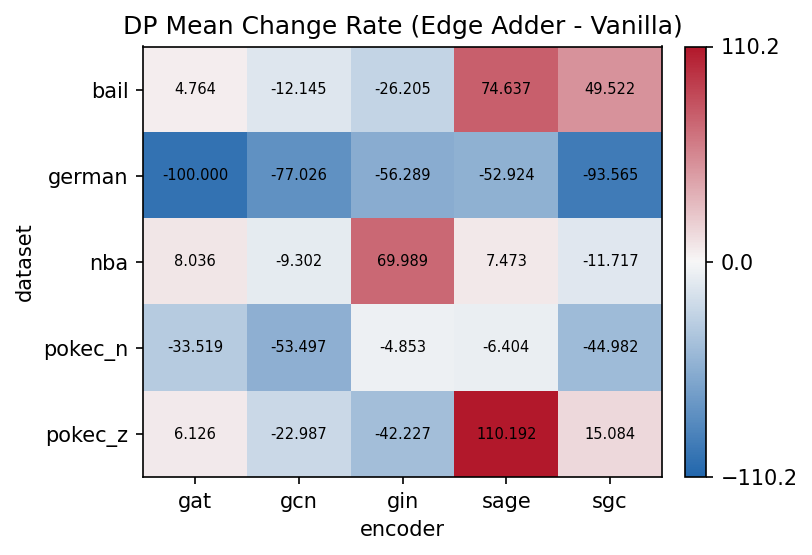

In [101]:
delta = pt_clean["DP_mean"]["edge_adder"] - pt_clean["DP_mean"]["vanilla"]
delta = delta / pt_clean["DP_mean"]["vanilla"]
heatmap_from_pivot(delta.unstack() * 100, title="DP Mean Change Rate (Edge Adder - Vanilla)")

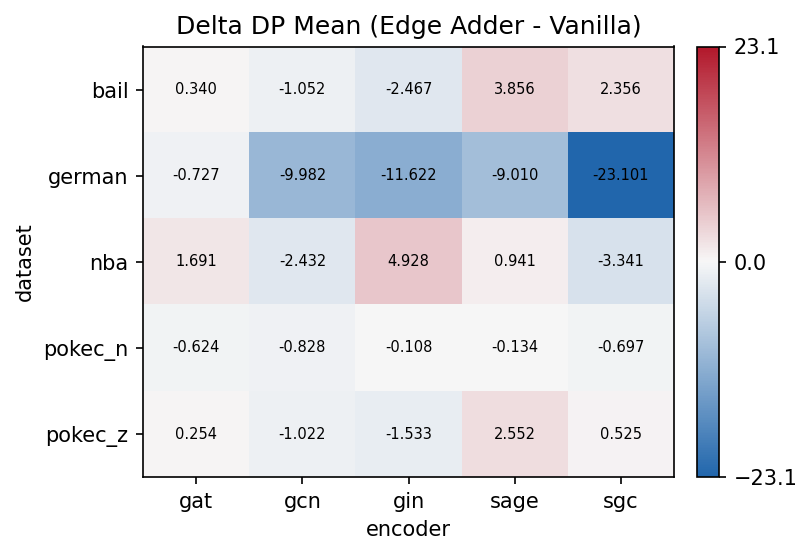

In [102]:
delta = pt_clean["DP_mean"]["edge_adder"] - pt_clean["DP_mean"]["vanilla"]
heatmap_from_pivot(delta.unstack() * 100, title="Delta DP Mean (Edge Adder - Vanilla)")

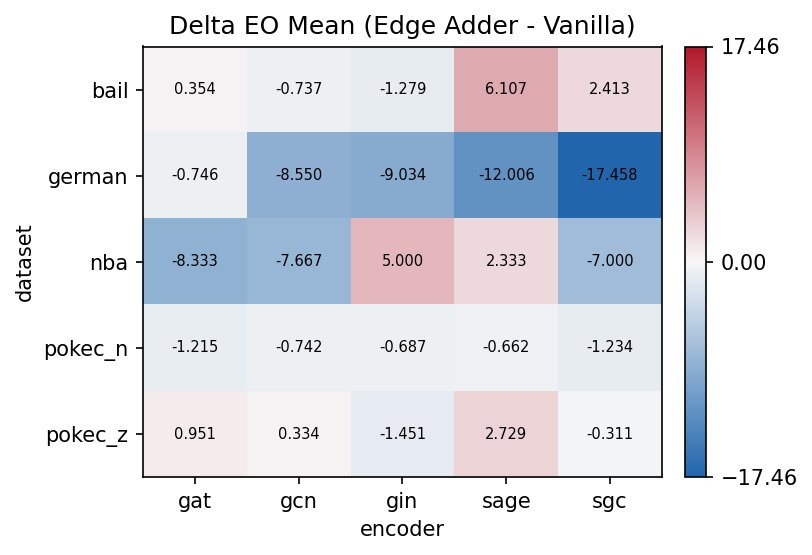

In [103]:
metric = "EO"
delta = pt_clean[f"{metric}_mean"]["edge_adder"] - pt_clean[f"{metric}_mean"]["vanilla"]
heatmap_from_pivot(delta.unstack() * 100, title=f"Delta {metric} Mean (Edge Adder - Vanilla)")

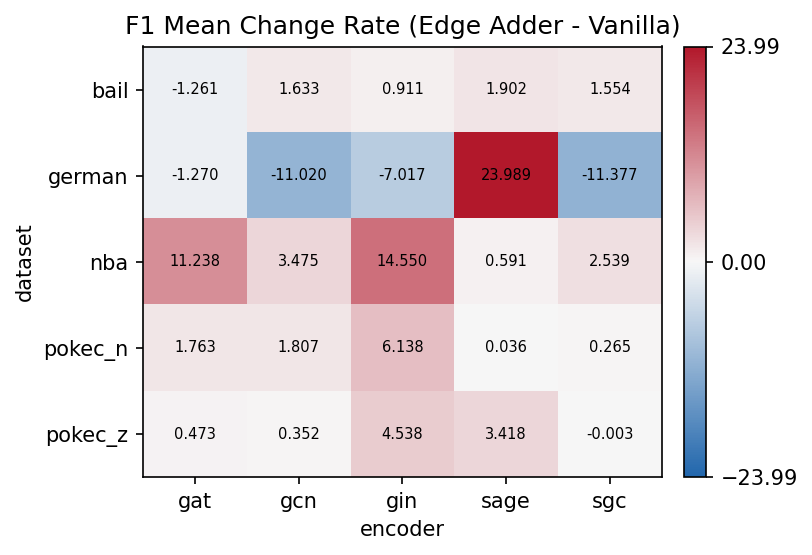

In [108]:
metric = "F1"
delta = pt_clean[f"{metric}_mean"]["edge_adder"] - pt_clean[f"{metric}_mean"]["vanilla"]
heatmap_from_pivot(delta.unstack() * 100, title=f"{metric} Mean Change Rate (Edge Adder - Vanilla)")

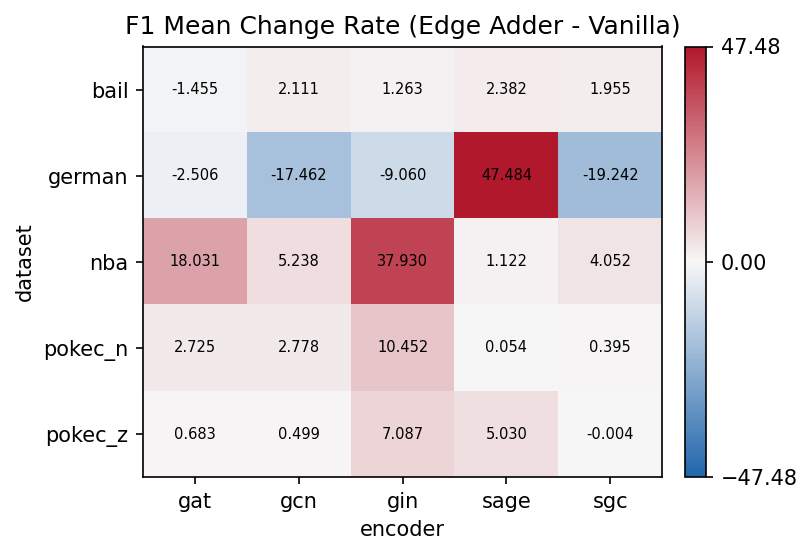

In [107]:
metric = "F1"
delta = pt_clean[f"{metric}_mean"]["edge_adder"] - pt_clean[f"{metric}_mean"]["vanilla"]
delta = delta / pt_clean[f"{metric}_mean"]["vanilla"]
heatmap_from_pivot(delta.unstack() * 100, title=f"{metric} Mean Change Rate (Edge Adder - Vanilla)")

### Degree NIFA

In [49]:
df1 = df_vanilla.loc[df_vanilla["attack_mode"] == "degree", :]
df2 = df_ea.loc[df_ea["attack_mode"] == "degree", :]
pt = pd.concat([df1, df2], axis=0)
pt["model"] = pd.Categorical(pt["model"], categories=["vanilla", "edge_adder"], ordered=True)
pt = pt.pivot_table(index=["dataset", "encoder"], columns="model", values=["AUC_mean", "F1_mean", "DP_mean", "EO_mean"], observed=False)
values = ["AUC_mean", "F1_mean", "DP_mean", "EO_mean"]
pt = pt[values]
round(pt, 4) * 100

AUC_mean            F1_mean            DP_mean             \
model            vanilla edge_adder vanilla edge_adder vanilla edge_adder   
dataset encoder                                                             
bail    gat        93.64      93.49   84.79      84.83    7.67       7.63   
        gcn        88.12      89.07   77.31      78.92    8.79       7.70   
        gin        84.45      83.55   71.98      72.92    9.75       7.51   
        sage       91.15      90.44   79.74      81.47    5.25       9.06   
        sgc        89.23      89.94   79.32      80.95    4.65       7.12   
german  gat        49.09      50.15   32.94      41.18    0.00       0.00   
        gcn        65.24      61.35   62.79      51.86   10.98       2.62   
        gin        68.80      67.91   77.59      70.75   19.54       7.88   
        sage       64.32      72.67   51.93      74.41   17.01       8.38   
        sgc        68.39      62.64   58.92      47.60   24.76       1.57   
nba     gat        65.80      75.22   61.83      74.78   19.04      23.70   
        gcn        72.79      73.21   66.84      68.29   31.39      25.22   
        gin        54.90      59.18   38.25      52.92    6.76      10.26   
        sage       63.61      64.67   52.63      52.83   11.40      13.15   
        sgc        71.76      72.57   61.78      66.24   31.87      34.31   
pokec_n gat        73.19      73.03   66.38      65.77   13.22       7.03   
        gcn        74.01      74.92   64.30      66.87    5.76       3.39   
        gin        69.27      72.37   57.24      65.10   11.10       7.31   
        sage       70.27      73.50   66.83      67.46    7.16       5.95   
        sgc        75.56      75.10   67.50      67.55    4.43       1.71   
pokec_z gat        76.83      71.56   69.47      66.91   15.41      24.26   
        gcn        77.42      76.37   70.10      70.24   15.45      14.83   
        gin        71.95      73.56   63.21      68.24   15.76       5.08   
        sage       72.38      76.86   66.94      71.05   14.44      16.97   
        sgc        76.93      76.10   70.91      70.88   14.34       9.40   

                EO_mean             
model           vanilla edge_adder  
dataset encoder                     
bail    gat        4.51       4.32  
        gcn        4.43       3.54  
        gin        6.68       5.58  
        sage       1.99       8.02  
        sgc        2.83       4.99  
german  gat        0.00       0.00  
        gcn       10.00       2.93  
        gin       16.42       7.33  
        sage      15.80       4.96  
        sgc       19.08       1.37  
nba     gat       20.67      12.33  
        gcn       20.33      12.00  
        gin        7.33       9.33  
        sage      11.67      14.67  
        sgc       23.67      22.00  
pokec_n gat        9.06       6.35  
        gcn        5.72       2.40  
        gin       13.35       6.54  
        sage       5.98       4.82  
        sgc        4.74       2.10  
pokec_z gat       12.06      21.82  
        gcn       11.46      11.40  
        gin       15.21       5.07  
        sage      13.58      15.05  
        sgc       10.48       6.69

# After 22 Dec 2025

In [13]:
datasets = ['bail', 'pokec_z', 'pokec_n', 'nba', 'german']
encoders = ['gcn', 'gat', 'gin', 'sage', 'sgc']
models = ['vanilla']

In [14]:
attack_mode = "no_attack"
path = f"../logs/scaled_use_tuned_hp/tuned_vanilla/"
df_vanilla_no_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_vanilla_no_attack.shape

(25, 15)

In [17]:
datasets = ['bail', 'pokec_z', 'pokec_n', 'nba', 'german']
encoders = ['gcn', 'gat', 'gin', 'sage', 'sgc']
models = ['edge_adder']

In [18]:
attack_mode = "no_attack"
path = f"../logs/scaled_use_tuned_hp/tuned_ea/{attack_mode}"
df_no_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_no_attack.shape

(25, 15)

In [75]:
df_attack = {}

for attack_mode in ["degree", "uncertainty"]:
    path = f"../logs/scaled_use_tuned_hp/tuned_ea/nifa_{attack_mode}"
    df_attack[attack_mode] = collect_rerun_results(
        datasets, encoders, models,
        path, attack_mode=attack_mode, verbose=False)
    df_attack[attack_mode]["attack_mode"] = attack_mode

In [105]:
df_attack_concat = pd.concat(df_attack.values()).sort_values(by=["dataset", "encoder", "model", "attack_mode"], ignore_index=True)

fn = "./main_tables/tuned_vanilla_default_nifa/main_table_all_attacks_mean.csv"
main_table_avg = pd.read_csv(fn)
print(main_table_avg.shape)
fn = "./main_tables/tuned_vanilla_default_nifa/main_table_all_attacks_std.csv"
main_table_std = pd.read_csv(fn)
print(main_table_std.shape)

selected = main_table_avg["selected"] == 1


cols = ["dataset", "encoder", "attack_mode"]
d1 = main_table_avg[selected][cols]
d2 = main_table_avg[selected][cols]
d3 = df_attack_concat[selected][cols]

if d1.equals(d3) and d2.equals(d3):
    print("The selected rows match between main_table and df_attack_concat")


(50, 16)
(50, 15)
The selected rows match between main_table and df_attack_concat


In [ ]:
def get_pt(main_table:pd.DataFrame, selected:pd.Series, stats:str, metric:str, df_attack_new:dict):
    pt_c = main_table[selected].pivot(index=["dataset"], columns="encoder", values=f"{metric}_{stats}_clean")
    pt_a = main_table[selected].pivot(index=["dataset"], columns="encoder", values=f"{metric}_{stats}_attacked")
    pt_d_old = main_table[selected].pivot(index=["dataset"], columns="encoder", values=f"{metric}_{stats}_defended")
    pt_d_new = df_attack_new[selected].pivot(index=["dataset"], columns="encoder", values=f"{metric}_{stats}")

    dfs = []
    for df, name in zip([pt_c, pt_a, pt_d_old, pt_d_new],
                        ["Clean", "Attacked", "Defended (old)", "Defended (new)"]):
        df["Setting"] = name
        dfs.append(df.reset_index())

    out = pd.concat(dfs, axis=0)
    out["Setting"] = pd.Categorical(
        out["Setting"], categories=["Clean", "Attacked", "Defended (old)", "Defended (new)"], ordered=True)
    return out.groupby(["dataset", "Setting"], observed=False).mean()

### DP

In [108]:
metric = "DP"
out_avg = get_pt(main_table_avg, selected=selected, stats="mean", metric=metric, df_attack_new=df_attack_concat)
out_std = get_pt(main_table_std, selected=selected, stats="std", metric=metric, df_attack_new=df_attack_concat)

display(round(out_avg, 4) * 100)
display(round(out_std, 4) * 100)

encoder                   gat    gcn    gin   sage    sgc
dataset Setting                                          
bail    Clean            7.51   6.24   9.43   2.44   4.38
        Attacked         7.42   6.38   9.44   3.81   4.41
        Defended (old)   7.13   4.03  10.31   3.53   3.68
        Defended (new)   7.59   3.41   8.51   5.96   3.30
german  Clean            6.13  32.04  25.04   8.28  24.71
        Attacked        19.28  25.56  28.96  11.15  22.17
        Defended (old)   9.32   8.00  15.51   4.59  17.26
        Defended (new)  11.45   3.24  12.18   6.92  22.47
nba     Clean           13.84  30.00   8.54   6.94  29.23
        Attacked        17.26  33.89   8.14   7.01  30.38
        Defended (old)  11.43  28.37   7.29   3.37  24.86
        Defended (new)   6.63  32.26  14.08  13.84  23.24
pokec_n Clean            1.11   1.56   2.21   1.39   1.23
        Attacked         1.63   2.82   6.62   1.83   4.00
        Defended (old)   2.05   1.77   4.67   4.58   2.84
        Defended (new)   1.49   2.93   2.08   1.96   3.64
pokec_z Clean            3.75   4.87   4.95   3.09   3.32
        Attacked         5.77   7.54   4.28   4.25   8.79
        Defended (old)   3.90   7.45   2.25   1.17   7.27
        Defended (new)   2.62   3.20   4.11   4.77   2.82

encoder                   gat    gcn    gin   sage    sgc
dataset Setting                                          
bail    Clean            0.37   0.28   1.28   1.93   0.39
        Attacked         0.53   0.79   0.63   2.21   0.55
        Defended (old)   0.67   0.71   1.30   2.00   0.30
        Defended (new)   0.81   0.90   1.28   4.50   0.66
german  Clean            4.62   9.14  10.49   7.99   7.97
        Attacked        14.51  10.03   9.21  10.72  10.47
        Defended (old)   8.89   3.42   9.92   5.04   3.04
        Defended (new)  11.63   2.06   8.71   5.26  11.94
nba     Clean            7.00   3.55   6.32   4.53   3.51
        Attacked        11.00   7.71   5.51   5.21   5.36
        Defended (old)   6.56   8.61   5.49   4.17   7.40
        Defended (new)   5.05   7.24  11.26   6.71   5.83
pokec_n Clean            0.89   1.35   2.14   1.28   0.63
        Attacked         0.92   2.57   8.41   1.34   1.51
        Defended (old)   2.04   1.25   3.94   2.29   0.77
        Defended (new)   1.84   1.51   1.43   1.14   2.38
pokec_z Clean            1.00   0.79   1.45   2.12   0.44
        Attacked         2.09   2.12   3.58   2.57   1.39
        Defended (old)   1.41   1.22   1.40   1.13   2.26
        Defended (new)   1.58   1.10   3.53   2.45   1.15

### EO

In [ ]:
metric = "EO"
out_avg = get_pt(main_table_avg, selected=selected, stats="mean", metric=metric, df_attack_new=df_attack_concat)
out_std = get_pt(main_table_std, selected=selected, stats="std", metric=metric, df_attack_new=df_attack_concat)

display(round(out_avg, 4) * 100)
display(round(out_std, 4) * 100)

encoder                   gat    gcn    gin   sage    sgc
dataset Setting                                          
bail    Clean            5.22   3.23   6.24   1.40   2.37
        Attacked         4.61   3.85   6.55   1.96   2.52
        Defended (old)   4.82   2.53   7.09   2.36   2.71
        Defended (new)   4.32   2.66   6.70   2.05   1.79
german  Clean            7.64  25.82  22.88   5.03  18.36
        Attacked        18.27  19.78  26.26   9.74  17.63
        Defended (old)   9.12   3.12  12.24   3.86  10.98
        Defended (new)  10.54   4.18   8.81   3.18  17.75
nba     Clean           21.33  28.00  15.67   5.67  18.67
        Attacked        25.67  27.67  11.67   8.00  20.33
        Defended (old)  13.00  18.00  13.00   8.33  12.00
        Defended (new)   6.67  20.67  14.67  11.33  12.00
pokec_n Clean            1.13   2.59   1.70   2.28   1.95
        Attacked         3.19   4.48   5.40   3.27   5.46
        Defended (old)   2.77   2.77   5.04   6.11   4.55
        Defended (new)   2.92   1.89   2.09   2.49   1.87
pokec_z Clean            3.96   2.96   4.85   3.95   3.09
        Attacked         4.96   5.96   4.79   4.51   7.25
        Defended (old)   3.03   6.95   2.35   1.36   7.92
        Defended (new)   3.21   2.18   3.31   4.99   2.42

encoder                   gat    gcn    gin   sage   sgc
dataset Setting                                         
bail    Clean            0.96   0.38   0.93   0.93  0.62
        Attacked         1.27   1.15   0.92   0.83  0.73
        Defended (old)   1.19   0.80   1.88   1.82  0.28
        Defended (new)   0.85   0.68   1.05   1.23  0.81
german  Clean            3.81   9.35  10.85   6.53  5.72
        Attacked        15.79  10.96  11.81  10.62  7.57
        Defended (old)   8.54   2.46  10.33   3.19  3.69
        Defended (new)  11.50   3.87   7.12   3.09  9.60
nba     Clean            9.33   6.00   7.16   5.78  6.53
        Attacked        16.74  12.91   7.78   7.02  5.47
        Defended (old)   7.52  13.35   9.83   6.37  6.36
        Defended (new)   3.33   8.67  12.84   5.21  9.33
pokec_n Clean            0.83   1.46   1.47   1.38  0.80
        Attacked         1.49   3.35   6.69   2.13  3.67
        Defended (old)   1.16   1.21   5.35   2.88  2.41
        Defended (new)   1.46   1.68   1.63   1.86  1.17
pokec_z Clean            1.32   0.68   1.67   1.58  1.09
        Attacked         1.74   1.90   3.65   2.45  1.58
        Defended (old)   1.43   1.84   1.35   1.15  2.19
        Defended (new)   1.28   0.85   3.61   2.75  1.36

### AUROC

In [110]:
metric = "AUC"
out_avg = get_pt(main_table_avg, selected=selected, stats="mean", metric=metric, df_attack_new=df_attack_concat)
out_std = get_pt(main_table_std, selected=selected, stats="std", metric=metric, df_attack_new=df_attack_concat)

display(round(out_avg, 4) * 100)
display(round(out_std, 4) * 100)

encoder                   gat    gcn    gin   sage    sgc
dataset Setting                                          
bail    Clean           94.18  90.48  85.36  91.56  88.77
        Attacked        94.21  90.17  85.10  91.71  88.70
        Defended (old)  91.86  90.93  85.50  92.21  89.94
        Defended (new)  94.24  88.86  85.68  91.07  89.44
german  Clean           56.65  74.27  68.34  62.55  69.79
        Attacked        57.36  73.60  68.14  65.86  68.09
        Defended (old)  54.21  70.46  65.99  60.35  66.82
        Defended (new)  50.71  66.00  69.05  68.90  67.97
nba     Clean           63.95  67.26  60.63  63.79  68.26
        Attacked        60.36  67.55  58.18  63.15  68.96
        Defended (old)  62.15  69.40  60.05  65.02  69.86
        Defended (new)  77.14  71.14  56.83  63.81  71.71
pokec_n Clean           75.56  75.48  69.87  73.32  75.51
        Attacked        75.10  75.65  67.25  73.30  75.03
        Defended (old)  75.44  75.65  67.08  72.62  74.70
        Defended (new)  75.96  76.21  67.95  74.28  74.89
pokec_z Clean           78.78  77.87  71.85  76.01  77.43
        Attacked        78.46  78.24  70.30  73.39  77.19
        Defended (old)  78.33  77.73  68.99  74.29  76.77
        Defended (new)  77.97  78.25  70.55  75.64  77.21

encoder                  gat   gcn   gin  sage   sgc
dataset Setting                                     
bail    Clean           1.05  0.14  1.05  0.58  0.16
        Attacked        0.77  1.31  0.59  0.43  0.40
        Defended (old)  1.13  0.84  1.33  0.86  0.16
        Defended (new)  1.03  1.02  0.92  0.68  0.23
german  Clean           2.89  1.18  2.67  7.25  1.19
        Attacked        4.25  1.26  1.95  6.73  3.62
        Defended (old)  2.17  2.09  2.18  7.97  2.17
        Defended (new)  3.67  5.33  2.70  3.78  1.56
nba     Clean           5.55  0.71  1.12  1.87  0.28
        Attacked        5.96  1.17  5.92  2.50  2.15
        Defended (old)  3.82  1.79  2.44  2.65  1.89
        Defended (new)  4.90  1.53  7.60  2.18  1.83
pokec_n Clean           0.44  1.13  1.05  0.61  0.09
        Attacked        0.60  0.48  1.24  0.89  0.39
        Defended (old)  0.55  0.27  1.69  0.32  0.41
        Defended (new)  0.39  0.31  1.55  0.32  0.56
pokec_z Clean           0.26  0.71  1.06  1.29  0.13
        Attacked        0.29  0.33  1.52  4.10  0.31
        Defended (old)  0.55  0.29  2.16  3.37  0.26
        Defended (new)  0.45  0.34  1.64  2.57  0.21

### F1-score

In [111]:
metric = "F1"
out_avg = get_pt(main_table_avg, selected=selected, stats="mean", metric=metric, df_attack_new=df_attack_concat)
out_std = get_pt(main_table_std, selected=selected, stats="std", metric=metric, df_attack_new=df_attack_concat)

display(round(out_avg, 4) * 100)
display(round(out_std, 4) * 100)

encoder                   gat    gcn    gin   sage    sgc
dataset Setting                                          
bail    Clean           86.70  80.86  74.42  82.60  78.73
        Attacked        86.84  80.43  74.63  82.02  78.52
        Defended (old)  82.64  82.94  74.12  82.81  80.40
        Defended (new)  86.65  78.68  75.34  79.63  79.25
german  Clean           55.21  76.04  62.42  57.17  63.49
        Attacked        59.01  67.46  68.53  58.99  60.08
        Defended (old)  61.09  68.36  70.90  48.92  64.36
        Defended (new)  49.69  62.46  63.64  70.23  65.87
nba     Clean           59.06  60.29  57.49  57.52  57.95
        Attacked        55.43  59.71  49.46  55.39  60.39
        Defended (old)  61.87  65.78  49.98  57.34  65.61
        Defended (new)  70.97  66.06  49.22  55.33  65.96
pokec_n Clean           67.29  62.94  62.44  67.05  67.41
        Attacked        66.38  65.27  61.02  66.04  66.82
        Defended (old)  66.35  63.45  60.59  66.23  65.81
        Defended (new)  65.54  67.07  60.43  66.78  67.44
pokec_z Clean           69.37  68.88  64.65  67.44  71.07
        Attacked        70.62  69.57  63.49  55.59  70.99
        Defended (old)  69.18  68.56  62.29  64.68  70.45
        Defended (new)  69.65  69.96  66.23  61.63  70.25

encoder                   gat    gcn    gin   sage    sgc
dataset Setting                                          
bail    Clean            1.72   0.66   1.83   1.64   0.59
        Attacked         1.61   1.10   2.17   1.53   0.98
        Defended (old)   1.95   1.58   3.01   2.26   0.33
        Defended (new)   1.53   1.34   1.33   4.00   0.58
german  Clean           17.15   6.89  22.48  32.85  18.58
        Attacked        11.76  14.13  10.60  27.87  16.42
        Defended (old)  13.87   7.22  19.04  33.52  11.15
        Defended (new)  28.71  24.98  20.66  17.66  18.28
nba     Clean            4.00   1.77   7.04   3.50   1.64
        Attacked         5.57   2.13  21.98   4.25   4.32
        Defended (old)   4.25   2.65  16.09   5.01   2.77
        Defended (new)  10.31   2.34  25.72   6.13   3.11
pokec_n Clean            1.17   8.68   1.52   0.79   1.23
        Attacked         1.17   3.50   1.13   1.62   1.07
        Defended (old)   1.91   3.66   2.84   0.87   1.72
        Defended (new)   2.78   0.91   3.53   1.55   0.69
pokec_z Clean            2.90   3.62   2.72   5.22   1.14
        Attacked         1.90   2.08   3.69  19.01   0.82
        Defended (old)   1.28   3.18   3.08   5.03   1.12
        Defended (new)   1.66   1.07   2.39  12.13   1.30

# After 14 Dec 2025

In [5]:
datasets = ['bail', 'pokec_z', 'pokec_n', 'nba', 'german']
encoders = ['gcn', 'gat', 'gin', 'sage', 'sgc']
models = ['vanilla']

In [6]:
df_clean_vanilla = pd.read_csv('./vanilla_rerun_tuned_results.csv')
df_clean_vanilla.shape

(25, 15)

### Vanill with DP + EO

In [ ]:
attack_mode = "no_attack"
path = f"../logs/tuned_vanilla_dp_eo/{attack_mode}"
df_no_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_no_attack.shape

FileNotFoundError: [Errno 2] No such file or directory: '../logs/tuned_vanilla_dp_eo/no_attack/bail/gcn/vanilla'

In [ ]:
df_no_attack["model"] = "vanilla_dp_eo"

In [ ]:
df_vanilla = concat_clean_and_attacked_results(df_clean_vanilla, df_no_attack, attack_mode=attack_mode)
df_vanilla.shape

(75, 14)

In [ ]:
df_vanilla.to_csv('./vanilla_dp_eo_no_attack_rerun_tuned_results.csv', index=False)

### NIFA degree

In [ ]:
attack_mode = "degree"
path = f"../logs/tuned_vanilla_dp_eo/nifa_{attack_mode}"
df_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_attack.shape

(25, 15)

In [ ]:
df_attack["model"] = "vanilla_dp_eo"
df_attack.to_csv('./vanilla_dp_eo_degree_rerun_tuned_results.csv', index=False)

In [ ]:
# df_degree = concat_clean_and_attacked_results(df_clean_vanilla, df_attack, attack_mode=attack_mode)
# df_degree.shape

(75, 14)

In [ ]:
# df_degree.to_csv(f'./edge_adder_rerun_before_and_after_nifa_{attack_mode}_no-dp_no-eo.csv', index=False)

### NIFA uncertainty

In [ ]:
attack_mode = "uncertainty"
path = f"../logs/tuned_vanilla_dp_eo/nifa_{attack_mode}"
df_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_attack.shape

(25, 15)

In [ ]:
df_attack["model"] = "vanilla_dp_eo"
df_attack.to_csv(f'./vanilla_dp_eo_{attack_mode}_rerun_tuned_results.csv', index=False)

In [ ]:
# df_uncertainty = concat_clean_and_attacked_results(df_clean_vanilla, df_attack, attack_mode=attack_mode)
# df_uncertainty.shape

(75, 14)

In [ ]:
# df_uncertainty.to_csv(f'./edge_adder_rerun_before_and_after_nifa_{attack_mode}_no-dp_no-eo.csv', index=False)

# After 1 Dec 2025

In [7]:
datasets = ['bail', 'pokec_z', 'pokec_n', 'nba', 'german']
encoders = ['gcn', 'gat', 'gin', 'sage', 'sgc']
models = ['edge_adder']

In [ ]:
df_clean_vanilla = pd.read_csv('./vanilla_rerun_tuned_results.csv')
df_clean_vanilla.shape

(25, 15)

### NIFA degree

In [16]:
attack_mode = "degree"
path = f"../logs/tuned_vanilla/nifa_{attack_mode}_no-dp_no-eo"
df_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_attack.shape

(25, 15)

In [17]:
df_degree = concat_clean_and_attacked_results(df_clean_vanilla, df_attack, attack_mode=attack_mode)
df_degree.shape

(75, 14)

In [19]:
df_degree.to_csv(f'./edge_adder_rerun_before_and_after_nifa_{attack_mode}_no-dp_no-eo.csv', index=False)

### NIFA uncertainty

In [20]:
attack_mode = "uncertainty"
path = f"../logs/tuned_vanilla/nifa_{attack_mode}_no-dp_no-eo"
df_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_attack.shape

(25, 15)

In [21]:
df_uncertainty = concat_clean_and_attacked_results(df_clean_vanilla, df_attack, attack_mode=attack_mode)
df_uncertainty.shape

(75, 14)

In [22]:
df_uncertainty.to_csv(f'./edge_adder_rerun_before_and_after_nifa_{attack_mode}_no-dp_no-eo.csv', index=False)

# After 25 Nov 2025

## Tuned Vanill + tuned NIFA + tuned EdgeAdder

In [5]:
datasets = ['bail', 'pokec_z', 'pokec_n', 'nba', 'german']
encoders = ['gcn', 'gat', 'gin', 'sage', 'sgc']
models = ['edge_adder']

### Collect results of non-attacked EdgeAdders

In [7]:
df_ea_tuned_nifa = pd.read_csv(f'./edge_adder_rerun_before_and_after_tuned_nifa.csv')
df_ea_tuned_nifa.head()

,dataset,encoder,model,attack_mode,AUC_mean,AUC_std,F1_mean,F1_std,ACC_mean,ACC_std,DP_mean,DP_std,EO_mean,EO_std
0,bail,gat,edge_adder,none,0.912052,0.009109,0.821841,0.018959,0.876987,0.011721,0.067483,0.003736,0.056587,0.008086
1,bail,gat,edge_adder,tuned_nifa,0.914833,0.007804,0.816527,0.020036,0.869421,0.010701,0.076924,0.008295,0.064049,0.015267
2,bail,gat,edge_adder,ratio,1.003050,0.856763,0.993534,1.056769,0.991374,0.912976,1.139911,2.220366,1.131870,1.888164
3,bail,gcn,edge_adder,none,0.909774,0.005378,0.818103,0.038729,0.855647,0.047632,0.042231,0.004242,0.026622,0.003642
4,bail,gcn,edge_adder,tuned_nifa,0.916215,0.003746,0.837381,0.010039,0.877389,0.011122,0.060023,0.009629,0.034615,0.007197


In [8]:
df_ea_clean = df_ea_tuned_nifa[df_ea_tuned_nifa['attack_mode']=='none'].reset_index(drop=True)
df_ea_clean.to_csv(f'./edge_adder_rerun_clean_nifa.csv', index=False)

In [10]:
df_clean_vanilla = pd.read_csv('./vanilla_rerun_tuned_results.csv')
df_clean_vanilla.shape

(25, 15)

In [20]:
EXP_NAME = "tuned_ea_obj"
attack_mode = "tuned_nifa"
path = f"../logs/use_tuned_vanilla_hp_run_ea/{EXP_NAME}/{attack_mode}"
df_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_attack.shape

(25, 15)

In [21]:
df_clean_vanilla.head()

,AUC_mean,AUC_std,F1_mean,F1_std,ACC_mean,ACC_std,DP_mean,DP_std,EO_mean,EO_std,name,dataset,encoder,model,attack_mode
0,0.941841,0.010481,0.866984,0.017238,0.904047,0.014456,0.075078,0.003705,0.052195,0.009622,vanilla_bail_gat_alpha:0.5_lr_sp:0.5_env_num:2...,bail,gat,vanilla,none
1,0.904786,0.001361,0.808645,0.006611,0.851134,0.008336,0.062429,0.002837,0.032345,0.003795,vanilla_bail_gcn_alpha:0.5_lr_sp:0.5_env_num:2...,bail,gcn,vanilla,none
2,0.853575,0.010490,0.744204,0.018288,0.791100,0.020788,0.094312,0.012849,0.062445,0.009313,vanilla_bail_gin_alpha:0.5_lr_sp:0.5_env_num:2...,bail,gin,vanilla,none
3,0.915551,0.005806,0.826009,0.016437,0.872007,0.021974,0.024374,0.019273,0.014033,0.009327,vanilla_bail_sage_alpha:0.5_lr_sp:0.5_env_num:...,bail,sage,vanilla,none
4,0.887652,0.001564,0.787315,0.005933,0.834796,0.007319,0.043767,0.003857,0.023688,0.006166,vanilla_bail_sgc_alpha:0.5_lr_sp:0.5_env_num:2...,bail,sgc,vanilla,none


In [22]:
df_attack.head()

,AUC_mean,AUC_std,F1_mean,F1_std,ACC_mean,ACC_std,DP_mean,DP_std,EO_mean,EO_std,name,dataset,encoder,model,attack_mode
1,0.911914,0.004847,0.816157,0.009177,0.871329,0.005306,0.070666,0.006135,0.056966,0.003526,edge_adder_bail_gat_alpha:0.5_lr_sp:0.5_env_nu...,bail,gat,edge_adder,tuned_nifa
0,0.895178,0.005965,0.800439,0.010109,0.848337,0.009860,0.032990,0.007113,0.022083,0.002381,edge_adder_bail_gcn_alpha:0.5_lr_sp:0.5_env_nu...,bail,gcn,edge_adder,tuned_nifa
2,0.853205,0.015190,0.734652,0.020219,0.779042,0.023911,0.108753,0.020859,0.070359,0.012636,edge_adder_bail_gin_alpha:0.5_lr_sp:0.5_env_nu...,bail,gin,edge_adder,tuned_nifa
3,0.916112,0.007488,0.838315,0.013733,0.886311,0.013231,0.044285,0.013602,0.034824,0.016122,edge_adder_bail_sage_alpha:0.5_lr_sp:0.5_env_n...,bail,sage,edge_adder,tuned_nifa
4,0.900177,0.007974,0.807182,0.009814,0.852384,0.008874,0.052306,0.007083,0.030218,0.004917,edge_adder_bail_sgc_alpha:0.5_lr_sp:0.5_env_nu...,bail,sgc,edge_adder,tuned_nifa


In [23]:
df_ea_tuned_nifa = concat_clean_and_attacked_results(df_clean_vanilla, df_attack, attack_mode=attack_mode)
df_ea_tuned_nifa.shape

(75, 14)

In [24]:
df_ea_tuned_nifa.to_csv(f'./edge_adder_rerun_before_and_after_tuned_nifa_obj.csv', index=False)

## Both versions of soft EO

In [26]:
df_clean_vanilla = pd.read_csv('./vanilla_rerun_tuned_results.csv')
df_clean_vanilla.shape

(25, 15)

In [16]:
datasets = ['bail', 'pokec_z', 'pokec_n', 'nba', 'german']
encoders = ['gcn', 'gat', 'gin', 'sage', 'sgc']
models = ['edge_adder']

### Tuned

In [27]:
EXP_NAME = "tuned_ea_obj_eo-both"
attack_mode = "tuned_nifa"
path = f"../logs/use_tuned_vanilla_hp_run_ea/{EXP_NAME}/{attack_mode}"
df_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_attack.shape

(25, 15)

In [28]:
df_ea_tuned_nifa = concat_clean_and_attacked_results(df_clean_vanilla, df_attack, attack_mode=attack_mode)
df_ea_tuned_nifa.shape

(75, 14)

In [29]:
df_ea_tuned_nifa.to_csv(f'./edge_adder_rerun_before_and_after_tuned_nifa_obj_eo-both.csv', index=False)

### NIFA degree (26-27 Nov 2025)

In [11]:
attack_mode = "degree"
path = f"../logs/tuned_vanilla/nifa_{attack_mode}_eo-both"
df_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_attack.shape

(25, 15)

In [13]:
df_ea_degree = concat_clean_and_attacked_results(df_clean_vanilla, df_attack, attack_mode=attack_mode)
df_ea_degree.shape

(75, 14)

In [14]:
df_ea_degree.to_csv(f'./edge_adder_rerun_before_and_after_nifa_{attack_mode}_eo-both.csv', index=False)

### NIFA uncertainty

In [17]:
attack_mode = "uncertainty"
path = f"../logs/tuned_vanilla/nifa_{attack_mode}_eo-both"
df_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_attack.shape

(25, 15)

In [18]:
df_ea_uncertainty = concat_clean_and_attacked_results(df_clean_vanilla, df_attack, attack_mode=attack_mode)
df_ea_uncertainty.shape

(75, 14)

In [19]:
df_ea_uncertainty.to_csv(f'./edge_adder_rerun_before_and_after_nifa_{attack_mode}_eo-both.csv', index=False)

# After 30 Oct 2025

## Vanilla

### Collect results of non-attacked vanilla GNNs

In [ ]:
ROOT = "./tuned_results/vanilla"
files = os.listdir(ROOT)
lst_data = []
for file in files:
    if not file.endswith('.json'):
        continue
    path = os.path.join(ROOT, file)
    with open(path, 'r') as f:
        data = json.load(f)
    reformatted_data = {
        "dataset": file.split("__")[0],
        "backbone": file.split('__')[1].split('_')[0],
        "model": "vanilla",
        "attack_mode": "none",
        "lambda_dp": 0.0,
        "lambda_eo": 0.0,
        "AUC_mean": data["auc"]["mean"],
        "AUC_std": data["auc"]["std"],
        "F1_mean": data["f1"]["mean"],
        "F1_std": data["f1"]["std"],
        "DP_mean": data["dp"]["mean"],
        "DP_std": data["dp"]["std"],
        "EO_mean": data["eo"]["mean"],
        "EO_std": data["eo"]["std"],
    }
    lst_data.append(reformatted_data)
df_clean_tuned = pd.DataFrame(lst_data)
df_clean_tuned.shape

(25, 14)

In [ ]:
df_clean_tuned.to_csv('./vanilla_tuned_results.csv', index=False)

In [145]:
datasets = ['bail', 'pokec_z', 'pokec_n', 'nba', 'german']
encoders = ['gcn', 'gat', 'gin', 'sage', 'sgc']
models = ['vanilla']

In [ ]:
df_clean_vanilla = collect_rerun_results(
    datasets, encoders, models,
    "../logs/tuned_vanilla/no_attack", attack_mode="none", verbose=False)
df_clean_vanilla.to_csv('./vanilla_rerun_tuned_results.csv', index=False)
df_clean_vanilla.shape

(25, 15)

### NIFA degree

In [6]:
attack_mode = "degree"
path = f"../logs/tuned_vanilla/nifa_{attack_mode}"
df_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_attack.shape

(25, 15)

In [7]:
df_vanilla_degree = concat_clean_and_attacked_results(df_clean_vanilla, df_attack, attack_mode=attack_mode)
df_vanilla_degree.shape

NameError: name 'df_clean_vanilla' is not defined

In [126]:
df_vanilla_degree.to_csv(f'./vanilla_rerun_before_and_after_nifa_{attack_mode}.csv', index=False)

### NIFA uncertainty

In [127]:
attack_mode = "uncertainty"
path = f"../logs/tuned_vanilla/nifa_{attack_mode}"
datasets = ['bail', 'pokec_z', 'pokec_n', 'nba', 'german']
encoders = ['gcn', 'gat', 'gin', 'sage', 'sgc']
models = ['vanilla']

df_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_attack.shape

(25, 15)

In [ ]:
df_vanilla_uncertainty = concat_clean_and_attacked_results(df_clean_vanilla, df_attack, attack_mode=attack_mode)
df_vanilla_uncertainty.shape

(75, 14)

In [129]:
df_vanilla_uncertainty.to_csv(f'./vanilla_rerun_before_and_after_nifa_{attack_mode}.csv', index=False)

### Tuned NIFA

In [14]:
df_clean_vanilla = pd.read_csv('./vanilla_rerun_tuned_results.csv')
df_clean_vanilla.shape

(25, 15)

In [15]:
attack_mode = "tuned_nifa"
path = f"../logs/tuned_vanilla/tuned_nifa"
datasets = ['bail', 'pokec_z', 'pokec_n', 'nba', 'german']
encoders = ['gcn', 'gat', 'gin', 'sage', 'sgc']
models = ['vanilla']

df_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_attack.shape

(25, 15)

In [16]:
df_vanilla_tuned_nifa = concat_clean_and_attacked_results(
    df_clean=df_clean_vanilla.loc[df_clean_vanilla['encoder'].isin(encoders), :],
    df_attack=df_attack,
    attack_mode=attack_mode,
    include_ratio=False
)
df_vanilla_tuned_nifa.shape

(50, 14)

In [17]:
df_vanilla_tuned_nifa.to_csv(f'./vanilla_rerun_before_and_after_{attack_mode}.csv', index=False)

## EdgeAdder

### Collect results of non-attacked EdgeAdders

In [8]:
datasets = ['bail', 'pokec_z', 'pokec_n', 'nba', 'german']
encoders = ['gcn', 'gat', 'gin', 'sage', 'sgc']
models = ['edge_adder']

In [7]:
path = "../logs/tuned_vanilla/no_attack"
verbose = False
lst_results = []
for dataset in datasets:
    for encoder in encoders:
        for model in models:
            results = get_result_json(dataset, encoder, model, path, verbose=verbose)
            if results:
                results['results']["dataset"] = dataset
                results['results']["encoder"] = encoder
                results['results']["model"] = model
                results['results']["attack_mode"] = "none"
                lst_results.append(results['results'])
df_clean = pd.DataFrame(lst_results).sort_values(by=["dataset", "encoder", "model"])
df_clean.shape

(25, 15)

### NIFA degree

In [135]:
attack_mode = "degree"
path = f"../logs/tuned_vanilla/nifa_{attack_mode}"
df_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_attack.shape

(25, 15)

In [136]:
df_degree = concat_clean_and_attacked_results(df_clean, df_attack, attack_mode=attack_mode)
df_degree.shape

(75, 14)

In [ ]:
df_degree.to_csv(f'./edge_adder_rerun_before_and_after_nifa_{attack_mode}.csv', index=False)

### NIFA uncertainty

In [138]:
attack_mode = "uncertainty"
path = f"../logs/tuned_vanilla/nifa_{attack_mode}"
df_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_attack.shape

(25, 15)

In [139]:
df_degree = concat_clean_and_attacked_results(df_clean, df_attack, attack_mode=attack_mode)
df_degree.shape

(75, 14)

In [140]:
df_degree.to_csv(f'./edge_adder_rerun_before_and_after_nifa_{attack_mode}.csv', index=False)

### Tuned NIFA (16 Nov 2025)

In [9]:
attack_mode = "tuned_nifa"
path = f"../logs/use_tuned_vanilla_hp_run_ea/tuned_ea/{attack_mode}"
df_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_attack.shape

(25, 15)

In [11]:
df_ea_tuned_nifa = concat_clean_and_attacked_results(df_clean, df_attack, attack_mode=attack_mode)
df_ea_tuned_nifa.shape

(75, 14)

In [13]:
df_ea_tuned_nifa.to_csv(f'./edge_adder_rerun_before_and_after_tuned_nifa.csv', index=False)

## FairINV (re-run) (Nov 7-8 2025)

### Collect results of non-attacked vanilla GNNs

In [31]:
ROOT = "./tuned_results/fairinv"
files = os.listdir(ROOT)
lst_data = []
for file in files:
    if not file.endswith('.json'):
        continue
    path = os.path.join(ROOT, file)
    with open(path, 'r') as f:
        data = json.load(f)
    reformatted_data = {
        "dataset": file.split("__")[0],
        "backbone": file.split('__')[1].split('_')[0],
        "model": "fairinv",
        "attack_mode": "none",
        "lambda_dp": 0.0,
        "lambda_eo": 0.0,
        "AUC_mean": data["auc"]["mean"],
        "AUC_std": data["auc"]["std"],
        "F1_mean": data["f1"]["mean"],
        "F1_std": data["f1"]["std"],
        "DP_mean": data["dp"]["mean"],
        "DP_std": data["dp"]["std"],
        "EO_mean": data["eo"]["mean"],
        "EO_std": data["eo"]["std"],
    }
    lst_data.append(reformatted_data)
df_clean_tuned = pd.DataFrame(lst_data)
df_clean_tuned = df_clean_tuned.sort_values(["dataset", "backbone", "model"])
df_clean_tuned.shape

(25, 14)

In [32]:
df_clean_tuned.to_csv('./fairinv_tuned_results.csv', index=False)

In [31]:
datasets = ['bail', 'pokec_z', 'pokec_n', 'nba', 'german']
encoders = ['gcn', 'gat', 'gin', 'sage', 'sgc']
models = ['fairinv']

In [39]:
path = "../logs/tuned_fairinv/no_attack"
verbose = False
lst_results = []
for dataset in datasets:
    for encoder in encoders:
        for model in models:
            results = get_result_json(dataset, encoder, model, path, verbose=verbose)
            if results:
                results['results']["dataset"] = dataset
                results['results']["encoder"] = encoder
                results['results']["model"] = model
                results['results']["attack_mode"] = "none"
                lst_results.append(results['results'])
df_clean = pd.DataFrame(lst_results).sort_values(by=["dataset", "encoder", "model"])
numeric_cols = ["AUC_mean", "AUC_std", "ACC_mean", "ACC_std", "F1_mean", "F1_std", "DP_mean", "DP_std", "EO_mean", "EO_std"]
df_clean = df_clean[["dataset", "encoder", "model", "attack_mode", "name"] + numeric_cols]
df_clean = df_clean.sort_values(by=["dataset", "encoder", "model"])
df_clean.shape

(25, 15)

In [42]:
df_clean.to_csv('./fairinv_rerrun_no_attack.csv', index=False)

In [43]:
df_clean = pd.read_csv('./fairinv_rerrun_no_attack.csv')
df_clean.shape

(25, 15)

### NIFA degree

In [44]:
attack_mode = "degree"
path = f"../logs/tuned_fairinv/nifa_{attack_mode}"
df_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_attack.shape

(25, 15)

In [45]:
df_degree = concat_clean_and_attacked_results(df_clean, df_attack, attack_mode=attack_mode)
df_degree.shape

(75, 14)

In [46]:
df_degree

,dataset,encoder,model,attack_mode,AUC_mean,AUC_std,ACC_mean,ACC_std,F1_mean,F1_std,DP_mean,DP_std,EO_mean,EO_std
0,bail,gat,fairinv,none,0.940794,0.010725,0.907756,0.008646,0.872354,0.012499,0.071863,0.004201,0.050695,0.006182
25,bail,gat,fairinv,degree,0.945272,0.004451,0.907184,0.004789,0.873024,0.006609,0.078328,0.005598,0.050842,0.008954
50,bail,gat,fairinv,ratio,1.058298,0.481462,1.060388,0.399946,1.084513,0.580133,1.092304,0.703383,1.271314,0.825950
1,bail,gcn,fairinv,none,0.893200,0.009244,0.855520,0.011975,0.804992,0.011393,0.071709,0.007959,0.039992,0.010840
26,bail,gcn,fairinv,degree,0.896153,0.019612,0.857321,0.014756,0.808678,0.019580,0.070759,0.013561,0.038354,0.011364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48,pokec_z,sage,fairinv,degree,0.781067,0.005191,0.707132,0.005252,0.701595,0.014363,0.072210,0.018909,0.059800,0.021109
73,pokec_z,sage,fairinv,ratio,1.084379,0.250283,0.988166,0.394308,0.849240,2.644642,1.002734,0.297417,1.522182,0.573461
24,pokec_z,sgc,fairinv,none,0.778381,0.000989,0.711146,0.002512,0.718527,0.003004,0.051039,0.003975,0.045143,0.004960
49,pokec_z,sgc,fairinv,degree,0.767816,0.002477,0.698870,0.005459,0.710668,0.002679,0.086277,0.022603,0.066457,0.013418


In [47]:
df_degree.to_csv(f'./fairinv_rerun_before_and_after_nifa_{attack_mode}.csv', index=False)

### NIFA uncertainty

In [48]:
attack_mode = "uncertainty"
path = f"../logs/tuned_fairinv/nifa_{attack_mode}"
df_attack = collect_rerun_results(
    datasets, encoders, models,
    path, attack_mode=attack_mode, verbose=False)
df_attack.shape

(25, 15)

In [49]:
df_uncertainty = concat_clean_and_attacked_results(df_clean, df_attack, attack_mode=attack_mode)
df_uncertainty.shape

(75, 14)

In [50]:
df_uncertainty.to_csv(f'./fairinv_rerun_before_and_after_nifa_{attack_mode}.csv', index=False)

# After 21 Oct 2025

## Use vanilla-tuned HPs to train with DP/EO loss only

In [3]:
def aggregate_results(datasets, encoders, models, root, verbose=False):
    verbose = False
    Results = {}
    lst_results = []
    lst_scenarios = []
    exps = os.listdir(root)
    exps.sort()
    for exp in exps:
        Results[exp] = {}
        path = os.path.join(root, exp)
        for dataset in datasets:
            for encoder in encoders:
                for model in models:
                    try:
                        results = get_result_json(dataset, encoder, model, path, verbose=verbose)
                        Results[exp][f'{dataset}_{encoder}_{model}'] = results
                        if verbose:
                            print(f'{dataset}_{encoder}_{model}:')
                            for metrics in ['auc', 'f1', 'dp', 'eo']:
                                m = results['results'][f'{metrics.upper()}_mean']
                                s = results['results'][f'{metrics.upper()}_std']
                                print(f'{m:.2%} ± {s:.2%}')
                    except Exception as e:
                        if verbose:
                            print(f'Error processing {dataset}_{encoder}_{model}: {e}')
                    if verbose:
                        print()
        for k in Results[exp].keys():
            lst_scenarios.append((exp, k))
            lst_results.append(Results[exp][k]['results'])

    df = pd.DataFrame(
        lst_results,
        index=pd.MultiIndex.from_tuples(lst_scenarios, names=['experiment', 'scenario'])
    ).reset_index()

    df["dataset"] = df["scenario"].apply(lambda x: x.split('_')[0] if "pokec" not in x else "_".join(x.split('_')[:2]))
    df["backbone"] = df["scenario"].apply(lambda x: x.split('_')[1] if "pokec" not in x else x.split('_')[2])
    df["model"] = df["scenario"].apply(lambda x: "_".join(x.split('_')[-2:]))
    df["lambda_dp"] = df["experiment"].apply(lambda x: float(x.split('_')[1]))
    df["lambda_eo"] = df["experiment"].apply(lambda x: float(x.split('_')[-1]))
    df = df[['dataset', 'backbone', 'model',
         'lambda_dp', 'lambda_eo',
         'AUC_mean', 'AUC_std',
         'F1_mean', 'F1_std',
         'DP_mean', 'DP_std',
         'EO_mean', 'EO_std']]

    return df.sort_values(by=['dataset', 'backbone', 'model', 'lambda_dp', 'lambda_eo'])

In [4]:
Results = {}
root = '../logs/use_tuned_vanilla_hp_run_ea'
exps = os.listdir(root)
exps.sort()

In [7]:
df = aggregate_results(
    datasets=['german', 'bail', 'pokec_z', 'pokec_n', 'nba'],
    encoders=['gcn', 'gat', 'gin', 'sage', 'sgc'],
    models=['edge_adder'],
    root=root,
    verbose=True
)
df.shape

(250, 13)

In [ ]:
df.to_csv('ea_non-mm/ea_dp_or_eo_only.csv', index=False)

In [11]:
c1 = df["dataset"] == "bail"
c2 = df["backbone"] == "gcn"
df[c1 & c2]

,dataset,backbone,model,lambda_dp,lambda_eo,AUC_mean,AUC_std,F1_mean,F1_std,DP_mean,DP_std,EO_mean,EO_std
55,bail,gcn,edge_adder,0.0,0.1,0.899686,0.001060,0.814338,0.006320,0.079437,0.005103,0.047908,0.002679
105,bail,gcn,edge_adder,0.0,0.5,0.903677,0.001196,0.814697,0.008266,0.077456,0.002199,0.046925,0.002508
5,bail,gcn,edge_adder,0.0,1.0,0.906182,0.000722,0.823771,0.006899,0.073847,0.001090,0.045550,0.003088
80,bail,gcn,edge_adder,0.0,5.0,0.912169,0.003030,0.832004,0.005512,0.049806,0.004960,0.030902,0.006870
30,bail,gcn,edge_adder,0.0,10.0,0.909127,0.003507,0.830681,0.006621,0.039144,0.005058,0.021785,0.004359
180,bail,gcn,edge_adder,0.1,0.0,0.897838,0.001284,0.812525,0.005426,0.079646,0.004410,0.049260,0.002294
230,bail,gcn,edge_adder,0.5,0.0,0.896280,0.001914,0.811033,0.008049,0.077971,0.004329,0.047313,0.003902
155,bail,gcn,edge_adder,1.0,0.0,0.896329,0.000971,0.806542,0.004967,0.079968,0.003027,0.047584,0.003830
205,bail,gcn,edge_adder,5.0,0.0,0.887059,0.001350,0.799062,0.004145,0.076512,0.002266,0.044546,0.001728
130,bail,gcn,edge_adder,10.0,0.0,0.881704,0.001065,0.787510,0.005320,0.075919,0.001857,0.041836,0.002130


## Concatenate with vanilla results

In [12]:
import json

In [19]:
ROOT = "./tuned_results/vanilla"
files = os.listdir(ROOT)
lst_data = []
for file in files:
    if not file.endswith('.json'):
        continue
    path = os.path.join(ROOT, file)
    with open(path, 'r') as f:
        data = json.load(f)
    reformatted_data = {
        "dataset": file.split("__")[0],
        "backbone": file.split('__')[1].split('_')[0],
        "model": "vanilla",
        "lambda_dp": 0.0,
        "lambda_eo": 0.0,
        "AUC_mean": data["auc"]["mean"],
        "AUC_std": data["auc"]["std"],
        "F1_mean": data["f1"]["mean"],
        "F1_std": data["f1"]["std"],
        "DP_mean": data["dp"]["mean"],
        "DP_std": data["dp"]["std"],
        "EO_mean": data["eo"]["mean"],
        "EO_std": data["eo"]["std"],
    }
    lst_data.append(reformatted_data)

In [24]:
df_vanilla = pd.DataFrame(lst_data)
df_concatenated = pd.concat([df, df_vanilla], ignore_index=True)
df_concatenated.sort_values(by=['dataset', 'backbone', 'lambda_dp', 'lambda_eo'], inplace=True)

In [25]:
c1 = df_concatenated["dataset"] == "bail"
c2 = df_concatenated["backbone"] == "gcn"
df_concatenated[c1 & c2]

,dataset,backbone,model,lambda_dp,lambda_eo,AUC_mean,AUC_std,F1_mean,F1_std,DP_mean,DP_std,EO_mean,EO_std
251,bail,gcn,vanilla,0.0,0.0,0.902179,0.001961,0.805811,0.009484,0.061524,0.001703,0.032869,0.004186
10,bail,gcn,edge_adder,0.0,0.1,0.899686,0.001060,0.814338,0.006320,0.079437,0.005103,0.047908,0.002679
11,bail,gcn,edge_adder,0.0,0.5,0.903677,0.001196,0.814697,0.008266,0.077456,0.002199,0.046925,0.002508
12,bail,gcn,edge_adder,0.0,1.0,0.906182,0.000722,0.823771,0.006899,0.073847,0.001090,0.045550,0.003088
13,bail,gcn,edge_adder,0.0,5.0,0.912169,0.003030,0.832004,0.005512,0.049806,0.004960,0.030902,0.006870
14,bail,gcn,edge_adder,0.0,10.0,0.909127,0.003507,0.830681,0.006621,0.039144,0.005058,0.021785,0.004359
15,bail,gcn,edge_adder,0.1,0.0,0.897838,0.001284,0.812525,0.005426,0.079646,0.004410,0.049260,0.002294
16,bail,gcn,edge_adder,0.5,0.0,0.896280,0.001914,0.811033,0.008049,0.077971,0.004329,0.047313,0.003902
17,bail,gcn,edge_adder,1.0,0.0,0.896329,0.000971,0.806542,0.004967,0.079968,0.003027,0.047584,0.003830
18,bail,gcn,edge_adder,5.0,0.0,0.887059,0.001350,0.799062,0.004145,0.076512,0.002266,0.044546,0.001728


In [26]:
df_concatenated.to_csv('ea_non-mm/ea_dp_or_eo_only_with_vanilla.csv', index=False)

# After 18 Oct 2025 (`ea_minmax`)

## Use edge-adder-tuned HPs with default min-max HPs

In [17]:
Results = {}
root = '../logs/runs_edge_minmax'

In [25]:
for dataset in ['german', 'bail', 'pokec_z', 'pokec_n', 'nba']:
    for encoder in ['gcn', 'gat', 'gin', 'sage', 'sgc']:
        for model in ['edge_minmax']:
            try:
                results = get_result_json(dataset, encoder, model, root)
                Results[f'{dataset}_{encoder}_{model}'] = results
                print(f'{dataset}_{encoder}_{model}:')
                for metrics in ['auc', 'f1', 'dp', 'eo']:
                    m = results['results'][f'{metrics.upper()}_mean']
                    s = results['results'][f'{metrics.upper()}_std']
                    print(f'{m:.2%} ± {s:.2%}')
            except Exception as e:
                print(f'Error processing {dataset}_{encoder}_{model}: {e}')
            print()


Found 1 log files in ../logs/runs_edge_minmax/german/gcn/edge_minmax/20251019-033815
german_gcn_edge_minmax:
74.44% ± 0.88%
67.91% ± 17.19%
32.03% ± 7.50%
25.78% ± 3.17%

Log directory does not exist: ../logs/runs_edge_minmax/german/gat/edge_minmax
german_gat_edge_minmax:
Error processing german_gat_edge_minmax: 'NoneType' object is not subscriptable

Found 1 log files in ../logs/runs_edge_minmax/german/gin/edge_minmax/20251019-041022
german_gin_edge_minmax:
68.77% ± 2.08%
74.16% ± 8.48%
20.60% ± 11.98%
18.60% ± 12.54%

Found 1 log files in ../logs/runs_edge_minmax/german/sage/edge_minmax/20251019-041440
german_sage_edge_minmax:
68.92% ± 4.90%
58.96% ± 20.16%
23.51% ± 11.14%
23.16% ± 11.58%

Found 1 log files in ../logs/runs_edge_minmax/german/sgc/edge_minmax/20251019-041114
german_sgc_edge_minmax:
70.18% ± 0.90%
66.19% ± 9.84%
28.09% ± 8.24%
22.50% ± 7.27%

Found 1 log files in ../logs/runs_edge_minmax/bail/gcn/edge_minmax/20251018-213200
bail_gcn_edge_minmax:
88.97% ± 0.56%
81.05% ± 

## Use default HPs

In [5]:
Results = {}
root = '../logs/runs/edge_minmax'

In [7]:
for dataset in ['german', 'bail', 'pokec_z', 'pokec_n', 'nba']:
    for encoder in ['gcn', 'gat']:
        for model in ['edge_minmax']:
            results = get_result_json(dataset, encoder, model, root)
            Results[f'{dataset}_{encoder}_{model}'] = results
            print(f'{dataset}_{encoder}_{model}:')
            for metrics in ['auc', 'f1', 'dp', 'eo']:
                m = results['results'][f'{metrics.upper()}_mean']
                s = results['results'][f'{metrics.upper()}_std']
                print(f'{m:.2%} ± {s:.2%}')

Found 1 log files in ../logs/runs/edge_minmax/german/gcn/edge_minmax/20251018-102209
german_gcn_edge_minmax:
67.39% ± 1.36%
59.67% ± 21.86%
24.12% ± 9.25%
19.89% ± 6.17%
Found 1 log files in ../logs/runs/edge_minmax/german/gat/edge_minmax/20251018-102341
german_gat_edge_minmax:
53.72% ± 7.61%
32.30% ± 39.59%
2.51% ± 7.31%
2.47% ± 7.13%
Found 1 log files in ../logs/runs/edge_minmax/bail/gcn/edge_minmax/20251018-103043
bail_gcn_edge_minmax:
85.81% ± 0.64%
74.78% ± 1.68%
7.69% ± 1.07%
4.36% ± 1.27%
Found 1 log files in ../logs/runs/edge_minmax/bail/gat/edge_minmax/20251018-103321
bail_gat_edge_minmax:
89.11% ± 0.75%
78.61% ± 1.30%
6.75% ± 0.76%
4.52% ± 1.18%
Found 1 log files in ../logs/runs/edge_minmax/pokec_z/gcn/edge_minmax/20251018-105147
pokec_z_gcn_edge_minmax:
77.99% ± 0.25%
72.05% ± 0.74%
5.17% ± 1.08%
3.86% ± 1.02%
Found 1 log files in ../logs/runs/edge_minmax/pokec_z/gat/edge_minmax/20251018-105244
pokec_z_gat_edge_minmax:
77.15% ± 0.83%
68.79% ± 2.14%
3.61% ± 1.62%
2.92% ± 1.69

In [ ]:
with open('all_results_0-9.json', 'w') as f:
    json.dump(Results, f, indent=4)

# Before 18 Oct 2025

## Seeds 42~51

In [ ]:
ROOT = '../logs/run/edge_adder'
Results = {}
for dataset in ['german', 'bail', 'pokec_z', 'pokec_n', 'nba']:
    for encoder in ['gcn', 'gat', 'gin', 'sage', 'sgc']:
        print(f"\nProcessing {dataset} with {encoder}")
        for model in ['edge_adder']:
            results = get_result_json(dataset, encoder, model, root=ROOT)
            Results[f'{dataset}_{encoder}_{model}'] = results
            print(f'{dataset}_{encoder}_{model}:')
            for metrics in ['auc', 'f1', 'dp', 'eo']:
                try:
                    m = results['results'][f'{metrics.upper()}_mean']
                    s = results['results'][f'{metrics.upper()}_std']
                except KeyError:
                    m = results['results']['SP_mean']
                    s = results['results']['SP_std']
                print(f'{m:.2%} ± {s:.2%}')


Processing german with gcn
Found 1 log files in ../logs/run/edge_adder/german/gcn/edge_adder/20250927-233744
german_gcn_edge_adder:
71.22% ± 1.98%
51.86% ± 22.07%
7.15% ± 4.20%
3.82% ± 2.99%

Processing german with gat
Found 1 log files in ../logs/run/edge_adder/german/gat/edge_adder/20250927-235613
german_gat_edge_adder:
53.14% ± 5.69%
41.12% ± 41.12%
0.13% ± 0.38%
0.17% ± 0.50%

Processing german with gin
Found 1 log files in ../logs/run/edge_adder/german/gin/edge_adder/20250927-235727
german_gin_edge_adder:
59.65% ± 8.43%
72.61% ± 16.72%
10.43% ± 10.89%
8.71% ± 10.63%

Processing german with sage
Found 1 log files in ../logs/run/edge_adder/german/sage/edge_adder/20250927-235850
german_sage_edge_adder:
61.18% ± 6.02%
38.01% ± 26.38%
15.12% ± 12.51%
15.53% ± 13.42%

Processing german with sgc
Found 1 log files in ../logs/run/edge_adder/german/sgc/edge_adder/20250927-234656
german_sgc_edge_adder:
68.10% ± 1.43%
40.21% ± 24.37%
6.23% ± 4.99%
4.23% ± 3.92%

Processing bail with gcn
Foun

In [ ]:
ROOT = '../logs/run/edge_adder'
Results = {}
for dataset in ['german', 'bail', 'pokec_z', 'pokec_n', 'nba']:
    for encoder in ['gcn']:
        for model in ['edge_adder']:
            results = get_result_json(dataset, encoder, model, root=ROOT)
            Results[f'{dataset}_{encoder}_{model}'] = results
            print(f'{dataset}_{encoder}_{model}:')
            for metrics in ['auc', 'f1', 'dp', 'eo']:
                try:
                    m = results['results'][f'{metrics.upper()}_mean']
                    s = results['results'][f'{metrics.upper()}_std']
                except KeyError:
                    m = results['results']['SP_mean']
                    s = results['results']['SP_std']
                print(f'{m:.2%} ± {s:.2%}')

In [24]:
import pickle as pkl

In [ ]:
with open('all_results_42-51.json', 'w') as f:
    json.dump(Results, f, indent=4)

## Seed 0~9

In [33]:
Results = {}
for dataset in ['german', 'bail', 'pokec_z', 'pokec_n', 'nba']:
    for encoder in ['gcn']:
        for model in ['vanilla', 'fairinv']:
            results = get_result_json(dataset, encoder, model)
            Results[f'{dataset}_{encoder}_{model}'] = results
            print(f'{dataset}_{encoder}_{model}:')
            for metrics in ['auc', 'f1', 'dp', 'eo']:
                m = results['results'][f'{metrics.upper()}_mean']
                s = results['results'][f'{metrics.upper()}_std']
                print(f'{m:.2%} ± {s:.2%}')

Found 1 log files in ./logs/german/gcn/vanilla/20250926-204322
german_gcn_vanilla:
70.68% ± 4.25%
62.53% ± 20.52%
12.14% ± 11.15%
10.59% ± 9.34%
Found 1 log files in ./logs/german/gcn/fairinv/20250926-204139
german_gcn_fairinv:
68.63% ± 1.35%
68.94% ± 26.71%
1.33% ± 1.84%
1.13% ± 1.62%
Found 1 log files in ./logs/bail/gcn/vanilla/20250926-204508
bail_gcn_vanilla:
90.61% ± 0.05%
80.56% ± 0.12%
6.44% ± 0.08%
3.23% ± 0.16%
Found 1 log files in ./logs/bail/gcn/fairinv/20250926-204535
bail_gcn_fairinv:
89.29% ± 1.42%
79.29% ± 2.35%
4.19% ± 1.25%
2.53% ± 0.95%
Found 1 log files in ./logs/pokec_z/gcn/vanilla/20250926-204752
pokec_z_gcn_vanilla:
75.06% ± 0.10%
68.79% ± 1.46%
4.71% ± 0.34%
4.77% ± 0.50%
Found 1 log files in ./logs/pokec_z/gcn/fairinv/20250926-205159
pokec_z_gcn_fairinv:
75.29% ± 0.84%
69.87% ± 0.56%
4.35% ± 1.05%
3.58% ± 1.11%
Found 1 log files in ./logs/pokec_n/gcn/vanilla/20250926-205029
pokec_n_gcn_vanilla:
72.72% ± 0.06%
64.04% ± 0.67%
0.66% ± 0.25%
2.07% ± 0.85%
Found 1 lo

In [ ]:
with open('all_results_0-9.json', 'w') as f:
    json.dump(Results, f, indent=4)

## Seeds 0 ~ 4 (5 runs)

In [35]:
Results = {}
for dataset in ['german', 'bail', 'pokec_z', 'pokec_n', 'nba']:
    for encoder in ['gcn']:
        for model in ['vanilla', 'fairinv']:
            results = get_result_json(dataset, encoder, model)
            Results[f'{dataset}_{encoder}_{model}'] = results
            print(f'{dataset}_{encoder}_{model}:')
            for metrics in ['auc', 'f1', 'dp', 'eo']:
                m = results['results'][f'{metrics.upper()}_mean']
                s = results['results'][f'{metrics.upper()}_std']
                print(f'{m:.2%} ± {s:.2%}')

Found 1 log files in ./logs/german/gcn/vanilla/20250926-211351
german_gcn_vanilla:
70.06% ± 4.00%
68.91% ± 16.21%
8.78% ± 9.17%
8.30% ± 8.23%
Found 1 log files in ./logs/german/gcn/fairinv/20250926-211500
german_gcn_fairinv:
68.30% ± 0.99%
82.26% ± 0.11%
0.72% ± 1.00%
0.55% ± 0.72%
Found 1 log files in ./logs/bail/gcn/vanilla/20250926-211422
bail_gcn_vanilla:
90.61% ± 0.04%
80.59% ± 0.10%
6.46% ± 0.05%
3.22% ± 0.15%
Found 1 log files in ./logs/bail/gcn/fairinv/20250926-211705
bail_gcn_fairinv:
88.59% ± 0.75%
78.36% ± 1.85%
4.77% ± 0.79%
2.67% ± 0.74%
Found 1 log files in ./logs/pokec_z/gcn/vanilla/20250926-211516
pokec_z_gcn_vanilla:
75.03% ± 0.14%
68.40% ± 1.97%
4.61% ± 0.40%
4.74% ± 0.65%
Found 1 log files in ./logs/pokec_z/gcn/fairinv/20250926-211949
pokec_z_gcn_fairinv:
75.60% ± 0.53%
70.02% ± 0.59%
3.83% ± 0.96%
3.33% ± 1.14%
Found 1 log files in ./logs/pokec_n/gcn/vanilla/20250926-211628
pokec_n_gcn_vanilla:
72.72% ± 0.07%
63.77% ± 0.59%
0.75% ± 0.22%
2.38% ± 0.80%
Found 1 log fi

In [36]:
with open('all_results_0-4.json', 'w') as f:
    json.dump(Results, f, indent=4)

In [48]:
Results = {}
for dataset in ['german', 'bail', 'pokec_z', 'pokec_n', 'nba']:
    Results[dataset] = {}
    for encoder in ['gat']:
        Results[dataset][encoder] = {}
        for model in ['vanilla', 'fairinv']:
            results = get_result_json(dataset, encoder, model)
            Results[dataset][encoder][model] = results
            print(f'{dataset}_{encoder}_{model}:')
            for metrics in ['auc', 'f1', 'dp', 'eo']:
                try:
                    m = results['results'][f'{metrics.upper()}_mean']
                    s = results['results'][f'{metrics.upper()}_std']
                except KeyError:
                    m = results['results']['SP_mean']
                    s = results['results']['SP_std']
                print(f'{m:.2%} ± {s:.2%}')

Found 1 log files in ./logs/german/gat/vanilla/20250927-113344
german_gat_vanilla:
52.75% ± 5.84%
16.47% ± 32.94%
0.00% ± 0.00%
0.00% ± 0.00%
Found 1 log files in ./logs/german/gat/fairinv/20250926-185751
german_gat_fairinv:
53.76% ± 3.74%
16.47% ± 32.94%
0.00% ± 0.00%
0.00% ± 0.00%
Found 1 log files in ./logs/bail/gat/vanilla/20250927-113728
bail_gat_vanilla:
93.17% ± 0.90%
84.60% ± 1.81%
7.50% ± 1.06%
4.23% ± 0.96%
Found 1 log files in ./logs/bail/gat/fairinv/20250926-190210
bail_gat_fairinv:
93.20% ± 1.04%
77.09% ± 9.07%
6.04% ± 1.04%
3.44% ± 1.91%
Found 1 log files in ./logs/pokec_z/gat/vanilla/20250927-114212
pokec_z_gat_vanilla:
76.13% ± 0.60%
70.00% ± 0.71%
4.71% ± 1.48%
4.48% ± 1.76%
Found 1 log files in ./logs/pokec_z/gat/fairinv/20250926-191027
pokec_z_gat_fairinv:
77.35% ± 0.71%
69.45% ± 2.95%
3.90% ± 1.93%
3.68% ± 2.10%
Found 1 log files in ./logs/pokec_n/gat/vanilla/20250927-114729
pokec_n_gat_vanilla:
73.71% ± 0.44%
65.80% ± 1.94%
1.53% ± 1.22%
1.82% ± 1.27%
Found 1 log f

In [49]:
for dataset in ['german', 'bail', 'pokec_z', 'pokec_n', 'nba']:
    for encoder in ['gin']:
        Results[dataset][encoder] = {}
        for model in ['vanilla', 'fairinv']:
            results = get_result_json(dataset, encoder, model)
            Results[dataset][encoder][model] = results
            print(f'{dataset}_{encoder}_{model}:')
            for metrics in ['auc', 'f1', 'dp', 'eo']:
                try:
                    m = results['results'][f'{metrics.upper()}_mean']
                    s = results['results'][f'{metrics.upper()}_std']
                except KeyError:
                    m = results['results']['SP_mean']
                    s = results['results']['SP_std']
                print(f'{m:.2%} ± {s:.2%}')

Found 1 log files in ./logs/german/gin/vanilla/20250926-195655
german_gin_vanilla:
55.89% ± 6.55%
62.04% ± 30.20%
9.17% ± 15.22%
9.50% ± 15.00%
Found 1 log files in ./logs/german/gin/fairinv/20250926-200251
german_gin_fairinv:
68.17% ± 2.64%
57.70% ± 37.77%
0.36% ± 0.56%
0.08% ± 0.25%
Found 1 log files in ./logs/bail/gin/vanilla/20250926-195745
bail_gin_vanilla:
84.45% ± 1.06%
72.52% ± 2.27%
7.88% ± 1.78%
4.94% ± 1.40%
Found 1 log files in ./logs/bail/gin/fairinv/20250926-200507
bail_gin_fairinv:
84.23% ± 1.43%
72.99% ± 2.24%
7.52% ± 2.21%
5.04% ± 1.72%
Found 1 log files in ./logs/pokec_z/gin/vanilla/20250926-195905
pokec_z_gin_vanilla:
70.93% ± 0.80%
66.58% ± 2.38%
5.17% ± 1.94%
5.31% ± 3.13%
Found 1 log files in ./logs/pokec_z/gin/fairinv/20250926-200848
pokec_z_gin_fairinv:
75.15% ± 0.34%
70.32% ± 1.20%
2.62% ± 2.38%
2.45% ± 2.03%
Found 1 log files in ./logs/pokec_n/gin/vanilla/20250926-200034
pokec_n_gin_vanilla:
69.63% ± 1.54%
61.06% ± 2.86%
2.10% ± 1.44%
2.48% ± 2.45%
Found 1 log

In [53]:
for dataset in ['german', 'bail', 'pokec_z', 'pokec_n', 'nba']:
    for encoder in ['sage']:
        Results[dataset][encoder] = {}
        for model in ['vanilla', 'fairinv']:
            results = get_result_json(dataset, encoder, model)
            Results[dataset][encoder][model] = results
            print(f'{dataset}_{encoder}_{model}:')
            for metrics in ['auc', 'f1', 'dp', 'eo']:
                try:
                    m = results['results'][f'{metrics.upper()}_mean']
                    s = results['results'][f'{metrics.upper()}_std']
                except KeyError:
                    m = results['results']['SP_mean']
                    s = results['results']['SP_std']
                print(f'{m:.2%} ± {s:.2%}')

Found 1 log files in ./logs/german/sage/vanilla/20250927-095950
german_sage_vanilla:
67.82% ± 3.20%
59.65% ± 23.25%
35.04% ± 14.14%
34.58% ± 14.54%
Found 1 log files in ./logs/german/sage/fairinv/20250927-112655
german_sage_fairinv:
69.74% ± 3.55%
82.21% ± 0.46%
1.76% ± 2.43%
0.72% ± 0.94%
Found 1 log files in ./logs/bail/sage/vanilla/20250927-100049
bail_sage_vanilla:
91.72% ± 0.63%
82.38% ± 1.93%
2.75% ± 2.52%
1.46% ± 1.29%
Found 1 log files in ./logs/bail/sage/fairinv/20250927-113014
bail_sage_fairinv:
91.03% ± 0.96%
81.17% ± 1.55%
1.17% ± 0.89%
1.28% ± 0.71%
Found 1 log files in ./logs/pokec_z/sage/vanilla/20250927-100225
pokec_z_sage_vanilla:
72.12% ± 1.14%
69.22% ± 0.89%
3.00% ± 1.48%
3.76% ± 1.91%
Found 1 log files in ./logs/pokec_z/sage/fairinv/20250927-113418
pokec_z_sage_fairinv:
78.12% ± 0.48%
71.14% ± 1.32%
5.10% ± 2.44%
4.60% ± 2.38%
Found 1 log files in ./logs/pokec_n/sage/vanilla/20250927-100423
pokec_n_sage_vanilla:
68.28% ± 1.32%
64.04% ± 1.43%
1.04% ± 0.87%
1.60% ± 1.

In [55]:
for dataset in ['german', 'bail', 'pokec_z', 'pokec_n', 'nba']:
    for encoder in ['sgc']:
        Results[dataset][encoder] = {}
        for model in ['vanilla', 'fairinv']:
            results = get_result_json(dataset, encoder, model)
            Results[dataset][encoder][model] = results
            print(f'{dataset}_{encoder}_{model}:')
            for metrics in ['auc', 'f1', 'dp', 'eo']:
                try:
                    m = results['results'][f'{metrics.upper()}_mean']
                    s = results['results'][f'{metrics.upper()}_std']
                except KeyError:
                    m = results['results']['SP_mean']
                    s = results['results']['SP_std']
                print(f'{m:.2%} ± {s:.2%}')

Found 1 log files in ./logs/german/sgc/vanilla/20250926-200446
german_sgc_vanilla:
68.45% ± 1.84%
55.93% ± 28.37%
13.55% ± 10.12%
11.46% ± 7.34%
Found 1 log files in ./logs/german/sgc/fairinv/20250927-122013
german_sgc_fairinv:
65.79% ± 1.28%
74.46% ± 23.33%
1.04% ± 1.26%
1.14% ± 1.39%
Found 1 log files in ./logs/bail/sgc/vanilla/20250926-200621
bail_sgc_vanilla:
88.24% ± 0.04%
78.01% ± 0.28%
4.72% ± 0.18%
3.40% ± 0.15%
Found 1 log files in ./logs/bail/sgc/fairinv/20250927-122330
bail_sgc_fairinv:
87.50% ± 0.75%
75.05% ± 2.74%
3.94% ± 1.37%
1.83% ± 0.94%
Found 1 log files in ./logs/pokec_z/sgc/vanilla/20250926-200847
pokec_z_sgc_vanilla:
76.90% ± 0.03%
70.65% ± 0.68%
3.09% ± 0.38%
3.22% ± 0.62%
Found 1 log files in ./logs/pokec_z/sgc/fairinv/20250927-122800
pokec_z_sgc_fairinv:
76.12% ± 1.19%
71.37% ± 0.50%
3.11% ± 1.80%
2.11% ± 1.72%
Found 1 log files in ./logs/pokec_n/sgc/vanilla/20250926-201229
pokec_n_sgc_vanilla:
75.11% ± 0.05%
67.04% ± 0.81%
1.46% ± 0.47%
1.47% ± 0.40%
Found 1 lo

In [60]:
with open('all_results_42-51.json', 'r') as f:
    Results_42_51 = json.load(f)
Results_42_51.keys()

dict_keys(['german_gcn_vanilla', 'german_gcn_fairinv', 'bail_gcn_vanilla', 'bail_gcn_fairinv', 'pokec_z_gcn_vanilla', 'pokec_z_gcn_fairinv', 'pokec_n_gcn_vanilla', 'pokec_n_gcn_fairinv', 'nba_gcn_vanilla', 'nba_gcn_fairinv'])

In [62]:
for k in Results_42_51.keys():
    k_split = k.split('_')
    dataset, encoder, model = k_split[0], k_split[1], k_split[2]
    if encoder != 'gcn':
        continue
    if encoder not in Results[dataset]:
        Results[dataset][encoder] = {}
    Results[dataset][encoder][model] = Results_42_51[k]

In [65]:
Results['german']['gcn']['vanilla']['results']

{'AUC_mean': 0.7161828571428572,
 'AUC_std': 0.030847160290036143,
 'F1_mean': 0.47361186680866013,
 'F1_std': 0.16334220857187437,
 'ACC_mean': 0.506,
 'ACC_std': 0.08679631328576115,
 'SP_mean': 0.14686306601200216,
 'SP_std': 0.07126286684567669,
 'EO_mean': 0.12195378151260505,
 'EO_std': 0.05854045408513699,
 'name': 'vanilla_german_gcn_alpha:10.0_lr_sp:0.1_env_num:2_lr:0.01'}

In [68]:
with open('all_encoder_results_42-51.json', 'w') as f:
    json.dump(Results, f, indent=4)

In [75]:
all_encoder_results_0_4 = {}
for dataset in ['german', 'bail', 'pokec_z', 'pokec_n']:
    all_encoder_results_0_4[dataset] = {}
    for encoder in ['gin']:
        all_encoder_results_0_4[dataset][encoder] = {}
        for model in ['vanilla', 'fairinv']:
            results = get_result_json(dataset, encoder, model)
            all_encoder_results_0_4[dataset][encoder][model] = results
            print(f'{dataset}_{encoder}_{model}:')
            for metrics in ['auc', 'f1', 'dp', 'eo']:
                try:
                    m = results['results'][f'{metrics.upper()}_mean']
                    s = results['results'][f'{metrics.upper()}_std']
                except KeyError:
                    m = results['results']['SP_mean']
                    s = results['results']['SP_std']
                print(f'{m:.2%} ± {s:.2%}')

Found 1 log files in ./logs/german/gin/vanilla/20250927-132259
german_gin_vanilla:
57.67% ± 10.00%
68.92% ± 23.95%
11.23% ± 11.10%
10.36% ± 10.81%
Found 1 log files in ./logs/german/gin/fairinv/20250927-132344
german_gin_fairinv:
63.84% ± 3.06%
33.21% ± 40.21%
0.34% ± 0.44%
0.17% ± 0.34%
Found 1 log files in ./logs/bail/gin/vanilla/20250927-132326
bail_gin_vanilla:
84.36% ± 0.84%
72.52% ± 2.15%
8.95% ± 1.64%
5.56% ± 1.85%
Found 1 log files in ./logs/bail/gin/fairinv/20250927-132515
bail_gin_fairinv:
84.11% ± 1.05%
72.60% ± 2.17%
7.90% ± 2.11%
5.71% ± 1.43%
Found 1 log files in ./logs/pokec_z/gin/vanilla/20250927-132415
pokec_z_gin_vanilla:
71.57% ± 1.09%
65.01% ± 3.37%
4.50% ± 1.11%
5.73% ± 1.07%
Found 1 log files in ./logs/pokec_z/gin/fairinv/20250927-132700
pokec_z_gin_fairinv:
73.84% ± 1.61%
69.66% ± 1.34%
1.69% ± 0.90%
0.83% ± 0.65%
Found 1 log files in ./logs/pokec_n/gin/vanilla/20250927-132515
pokec_n_gin_vanilla:
70.81% ± 0.56%
62.16% ± 1.06%
0.94% ± 0.53%
1.25% ± 0.86%
Found 1 

In [76]:
for dataset in ['german', 'bail', 'pokec_z', 'pokec_n']:
    for encoder in ['sage']:
        all_encoder_results_0_4[dataset][encoder] = {}
        for model in ['vanilla', 'fairinv']:
            results = get_result_json(dataset, encoder, model)
            all_encoder_results_0_4[dataset][encoder][model] = results
            print(f'{dataset}_{encoder}_{model}:')
            for metrics in ['auc', 'f1', 'dp', 'eo']:
                try:
                    m = results['results'][f'{metrics.upper()}_mean']
                    s = results['results'][f'{metrics.upper()}_std']
                except KeyError:
                    m = results['results']['SP_mean']
                    s = results['results']['SP_std']
                print(f'{m:.2%} ± {s:.2%}')

Found 1 log files in ./logs/german/sage/vanilla/20250927-132809
german_sage_vanilla:
66.06% ± 2.48%
52.39% ± 15.79%
27.73% ± 6.96%
29.14% ± 6.36%
Found 1 log files in ./logs/german/sage/fairinv/20250927-134114
german_sage_fairinv:
72.29% ± 4.19%
69.74% ± 22.88%
7.17% ± 4.59%
4.45% ± 2.25%
Found 1 log files in ./logs/bail/sage/vanilla/20250927-132904
bail_sage_vanilla:
91.42% ± 0.28%
81.24% ± 2.84%
1.77% ± 3.13%
1.13% ± 0.61%
Found 1 log files in ./logs/bail/sage/fairinv/20250927-134241
bail_sage_fairinv:
91.43% ± 0.69%
81.15% ± 1.44%
0.64% ± 0.64%
1.14% ± 1.06%
Found 1 log files in ./logs/pokec_z/sage/vanilla/20250927-133015
pokec_z_sage_vanilla:
72.97% ± 0.93%
69.05% ± 1.82%
3.22% ± 1.46%
2.21% ± 1.44%
Found 1 log files in ./logs/pokec_z/sage/fairinv/20250927-134443
pokec_z_sage_fairinv:
77.70% ± 1.29%
71.72% ± 1.06%
4.57% ± 3.13%
4.57% ± 2.59%
Found 1 log files in ./logs/pokec_n/sage/vanilla/20250927-133130
pokec_n_sage_vanilla:
70.77% ± 0.59%
64.98% ± 0.64%
1.65% ± 1.14%
0.87% ± 0.4

In [77]:
with open('gin_sage_results_0_4.json', 'w') as f:
    json.dump(all_encoder_results_0_4, f, indent=4)